In [ ]:
import numpy as np
import pytest
from numpy.testing import assert_array_almost_equal
from numpy.testing import assert_equal

from landlab import HexModelGrid
from landlab import RasterModelGrid
from landlab.components.diffusion import LinearDiffuser

# pip install pytest

In [ ]:
import numpy as np
import pytest
from numpy.testing import assert_array_almost_equal
from numpy.testing import assert_equal

from landlab import HexModelGrid
from landlab import RasterModelGrid
from landlab.components.diffusion import LinearDiffuser

# pip install pytest


def test_diffusion():
    #Time step
    dt = 1.0
    #End time
    time_to_run = 3.0
    # Intitial topography elevation
    init_elev = 0.0
    # Grid
    mg = RasterModelGrid((20, 10), xy_spacing=(100.0, 100.0))
    # Uplift
    uplift_rate = mg.node_y[mg.core_cells] / 100000.0
    # create the fields in the grid
    mg.add_zeros("topographic__elevation", at="node")
    z = mg.zeros(at="node") + init_elev
    np.random.seed(0)
    mg["node"]["topographic__elevation"] = z + np.random.rand(len(z)) / 1000.0
    
    # Boundary
    mg.set_fixed_value_boundaries_at_grid_edges(True, True, True, True)

    # Diffusion
    dfn = LinearDiffuser(mg, linear_diffusivity=50000.0)

    # perform the loop:
    elapsed_time = 0.0  # total time in simulation
    while elapsed_time < time_to_run:
        if elapsed_time + dt > time_to_run:
            dt = time_to_run - elapsed_time
        dfn.run_one_step(dt)
        mg.at_node["topographic__elevation"][mg.core_nodes] += uplift_rate * dt
        elapsed_time += dt

    z_target = np.array(
        [
            5.48813504e-04,
            7.15189366e-04,
            6.02763376e-04,
            5.44883183e-04,
            4.23654799e-04,
            6.45894113e-04,
            4.37587211e-04,
            8.91773001e-04,
            9.63662761e-04,
            3.83441519e-04,
            7.91725038e-04,
            9.18166135e-04,
            1.02015039e-03,
            1.10666198e-03,
            1.14866514e-03,
            1.20224288e-03,
            1.12953135e-03,
            1.12966219e-03,
            1.00745155e-03,
            8.70012148e-04,
            9.78618342e-04,
            1.12628772e-03,
            1.41663596e-03,
            2.66338249e-03,
            2.80420703e-03,
            2.82445061e-03,
            2.69263914e-03,
            2.44620140e-03,
            2.04237613e-03,
            4.14661940e-04,
            2.64555612e-04,
            2.15073330e-03,
            2.77965579e-03,
            3.22134736e-03,
            3.45859244e-03,
            4.47224671e-03,
            4.25371135e-03,
            3.82941648e-03,
            3.25127747e-03,
            6.81820299e-04,
            3.59507901e-04,
            3.36577718e-03,
            4.20490812e-03,
            4.81467159e-03,
            5.14099588e-03,
            5.15029835e-03,
            4.83533539e-03,
            5.22312276e-03,
            4.37284689e-03,
            3.63710771e-04,
            5.70196770e-04,
            4.65122535e-03,
            5.67854747e-03,
            6.44757828e-03,
            6.85985389e-03,
            6.86464781e-03,
            6.45159799e-03,
            5.65255723e-03,
            4.54258827e-03,
            2.44425592e-04,
            1.58969584e-04,
            5.85971567e-03,
            7.16648352e-03,
            8.10954246e-03,
            8.61082386e-03,
            8.61350727e-03,
            8.10597021e-03,
            7.12594182e-03,
            5.75483957e-03,
            9.60984079e-05,
            9.76459465e-04,
            6.29476234e-03,
            7.70594852e-03,
            9.79504842e-03,
            1.03829367e-02,
            1.03869062e-02,
            9.79374998e-03,
            8.65447904e-03,
            7.07179252e-03,
            1.18727719e-04,
            3.17983179e-04,
            7.43078552e-03,
            9.18353155e-03,
            1.04682910e-02,
            1.11542648e-02,
            1.21643980e-02,
            1.14930584e-02,
            1.02184219e-02,
            8.53727126e-03,
            9.29296198e-04,
            3.18568952e-04,
            8.68034110e-03,
            1.06702554e-02,
            1.21275181e-02,
            1.29049224e-02,
            1.29184938e-02,
            1.21616788e-02,
            1.17059081e-02,
            9.66728348e-03,
            4.69547619e-06,
            6.77816537e-04,
            1.00128306e-02,
            1.21521279e-02,
            1.37494046e-02,
            1.46053573e-02,
            1.46205669e-02,
            1.37908840e-02,
            1.22146332e-02,
            1.01165765e-02,
            9.52749012e-04,
            4.47125379e-04,
            1.12069867e-02,
            1.35547122e-02,
            1.52840440e-02,
            1.62069802e-02,
            1.62196380e-02,
            1.53169489e-02,
            1.35997836e-02,
            1.12818577e-02,
            6.92531590e-04,
            7.25254280e-04,
            1.14310516e-02,
            1.38647655e-02,
            1.66771925e-02,
            1.76447108e-02,
            1.76515649e-02,
            1.66885162e-02,
            1.48507549e-02,
            1.23206170e-02,
            2.90077607e-04,
            6.18015429e-04,
            1.24952067e-02,
            1.49924260e-02,
            1.68435913e-02,
            1.78291009e-02,
            1.88311310e-02,
            1.78422046e-02,
            1.59665841e-02,
            1.34122052e-02,
            4.31418435e-04,
            8.96546596e-04,
            1.34612553e-02,
            1.58763600e-02,
            1.76887976e-02,
            1.86526609e-02,
            1.86492669e-02,
            1.76752679e-02,
            1.68480793e-02,
            1.44368883e-02,
            9.98847007e-04,
            1.49448305e-04,
            1.40672989e-02,
            1.64140227e-02,
            1.81162514e-02,
            1.90091351e-02,
            1.89959971e-02,
            1.80757625e-02,
            1.63425116e-02,
            1.39643530e-02,
            6.91669955e-05,
            6.97428773e-04,
            1.47340964e-02,
            1.66453353e-02,
            1.80835612e-02,
            1.88335770e-02,
            1.88048458e-02,
            1.80022362e-02,
            1.65110248e-02,
            1.44854151e-02,
            1.71629677e-04,
            5.21036606e-04,
            1.40633664e-02,
            1.54867652e-02,
            1.75865008e-02,
            1.81309867e-02,
            1.80760242e-02,
            1.74501109e-02,
            1.63343931e-02,
            1.48208186e-02,
            3.18389295e-05,
            1.64694156e-04,
            1.41550038e-02,
            1.49870334e-02,
            1.57563641e-02,
            1.60213295e-02,
            1.69074625e-02,
            1.64888825e-02,
            1.58787450e-02,
            1.50671910e-02,
            3.11944995e-04,
            3.98221062e-04,
            2.09843749e-04,
            1.86193006e-04,
            9.44372390e-04,
            7.39550795e-04,
            4.90458809e-04,
            2.27414628e-04,
            2.54356482e-04,
            5.80291603e-05,
            4.34416626e-04,
        ]
    )

    assert_array_almost_equal(mg.at_node["topographic__elevation"], z_target)

    # ============================================================
# WRITE REFERENCE AND FINAL TOPOGRAPHY FILES
# ============================================================

# ------------------------------------------------------------
# REFERENCE SOLUTION
# ------------------------------------------------------------

reference_file = "z_target_reference.txt"

with open(reference_file, "w") as f:

    f.write("# x y z_target\n")

    for y in range(mg.shape[0]):

        for x in range(mg.shape[1]):

            node_id = y * mg.shape[1] + x

            xcoord = mg.node_x[node_id]
            ycoord = mg.node_y[node_id]

            zvalue = z_target[node_id]

            f.write(
                f"{xcoord:.0f} "
                f"{ycoord:.0f} "
                f"{zvalue:.15f}\n"
            )

print(
    f"\nReference topography file written: "
    f"{reference_file}"
)

# ------------------------------------------------------------
# FINAL SIMULATED TOPOGRAPHY
# ------------------------------------------------------------

final_file = "z_final_reference.txt"

with open(final_file, "w") as f:

    f.write("# x y z_final\n")

    for y in range(mg.shape[0]):

        for x in range(mg.shape[1]):

            node_id = y * mg.shape[1] + x

            xcoord = mg.node_x[node_id]
            ycoord = mg.node_y[node_id]

            zvalue = z_final[node_id]

            f.write(
                f"{xcoord:.0f} "
                f"{ycoord:.0f} "
                f"{zvalue:.15f}\n"
            )

print(
    f"\nFinal simulated topography file written: "
    f"{final_file}"
)


Reference topography file written: z_target_reference.txt

Final simulated topography file written: z_final_reference.txt


Initial mass = 0.100088

Index diagnostics:
core_nodes : 144
core_cells : 144
uplift_rate: 144

Final mass   = 1.739168
Mass change  = 1.639081e+00

Running regression test ...

TEST PASSED
Model reproduces the original Landlab benchmark.

Maximum absolute error:
0.0021658060322373093

Mean absolute error:
0.000738145606990327


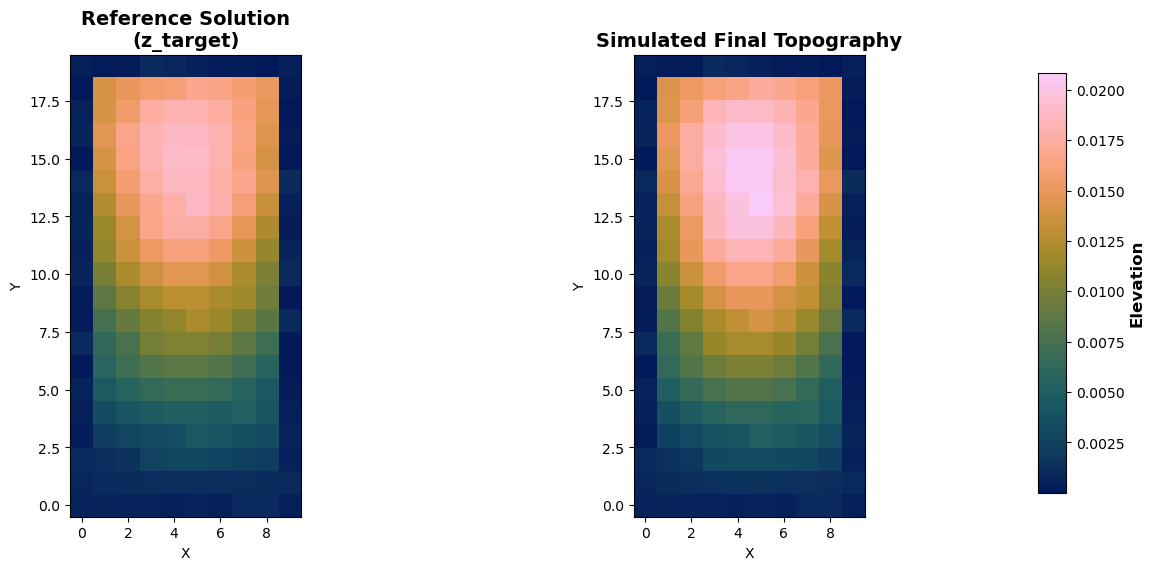

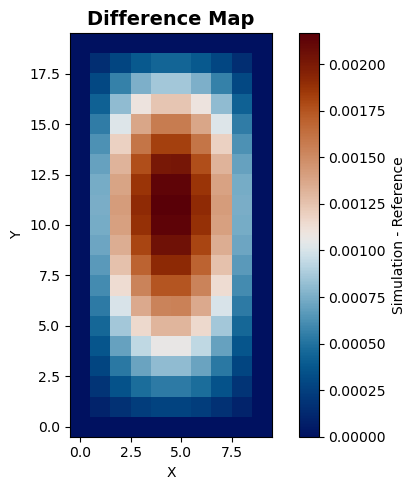


Simulation completed.

Peak elevation = 0.020845


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cmcrameri.cm as cmc

from numpy.testing import assert_array_almost_equal

from landlab import RasterModelGrid
from landlab.components import LinearDiffuser

# ============================================================
# PARAMETERS
# ============================================================

dt = 1.0
time_to_run = 3.0

init_elev = 0.0

# ============================================================
# CREATE GRID
# ============================================================

mg = RasterModelGrid(
    (20, 10),
    xy_spacing=(100.0, 100.0)
)

# ============================================================
# UPLIFT FIELD
# EXACT ORIGINAL LANDLAB IMPLEMENTATION
# ============================================================

uplift_rate = mg.node_y[mg.core_cells] / 100000.0

# ============================================================
# INITIAL TOPOGRAPHY
# ============================================================

mg.add_zeros(
    "topographic__elevation",
    at="node"
)

z = mg.zeros(at="node") + init_elev

np.random.seed(0)

mg.at_node["topographic__elevation"] = (
    z + np.random.rand(len(z)) / 1000.0
)

# store initial topography
z_initial = mg.at_node[
    "topographic__elevation"
].copy()

# ============================================================
# BOUNDARY CONDITIONS
# ============================================================

mg.set_fixed_value_boundaries_at_grid_edges(
    True,
    True,
    True,
    True
)

# ============================================================
# INITIAL MASS
# ============================================================

initial_mass = np.sum(
    mg.at_node["topographic__elevation"]
)

print(f"Initial mass = {initial_mass:.6f}")

# ============================================================
# CREATE DIFFUSER
# ============================================================

dfn = LinearDiffuser(
    mg,
    linear_diffusivity=50000.0
)

# ============================================================
# INDEX DIAGNOSTICS
# ============================================================

print("\nIndex diagnostics:")

print("core_nodes :", len(mg.core_nodes))
print("core_cells :", len(mg.core_cells))
print("uplift_rate:", len(uplift_rate))

# ============================================================
# RUN MODEL
# ============================================================

elapsed_time = 0.0

while elapsed_time < time_to_run:

    if elapsed_time + dt > time_to_run:
        dt = time_to_run - elapsed_time

    # diffusion
    dfn.run_one_step(dt)

    # uplift
    mg.at_node["topographic__elevation"][
        mg.core_nodes
    ] += uplift_rate * dt

    elapsed_time += dt

# ============================================================
# FINAL TOPOGRAPHY
# ============================================================

z_final = mg.at_node[
    "topographic__elevation"
].copy()

# ============================================================
# FINAL MASS
# ============================================================

final_mass = np.sum(z_final)

print(f"\nFinal mass   = {final_mass:.6f}")

print(
    f"Mass change  = "
    f"{final_mass - initial_mass:.6e}"
)

# ============================================================
# REFERENCE SOLUTION
# ============================================================

z_target = np.array(
[
    5.48813504e-04,
    7.15189366e-04,
    6.02763376e-04,
    5.44883183e-04,
    4.23654799e-04,
    6.45894113e-04,
    4.37587211e-04,
    8.91773001e-04,
    9.63662761e-04,
    3.83441519e-04,
    7.91725038e-04,
    9.18166135e-04,
    1.02015039e-03,
    1.10666198e-03,
    1.14866514e-03,
    1.20224288e-03,
    1.12953135e-03,
    1.12966219e-03,
    1.00745155e-03,
    8.70012148e-04,
    9.78618342e-04,
    1.12628772e-03,
    1.41663596e-03,
    2.66338249e-03,
    2.80420703e-03,
    2.82445061e-03,
    2.69263914e-03,
    2.44620140e-03,
    2.04237613e-03,
    4.14661940e-04,
    2.64555612e-04,
    2.15073330e-03,
    2.77965579e-03,
    3.22134736e-03,
    3.45859244e-03,
    4.47224671e-03,
    4.25371135e-03,
    3.82941648e-03,
    3.25127747e-03,
    6.81820299e-04,
    3.59507901e-04,
    3.36577718e-03,
    4.20490812e-03,
    4.81467159e-03,
    5.14099588e-03,
    5.15029835e-03,
    4.83533539e-03,
    5.22312276e-03,
    4.37284689e-03,
    3.63710771e-04,
    5.70196770e-04,
    4.65122535e-03,
    5.67854747e-03,
    6.44757828e-03,
    6.85985389e-03,
    6.86464781e-03,
    6.45159799e-03,
    5.65255723e-03,
    4.54258827e-03,
    2.44425592e-04,
    1.58969584e-04,
    5.85971567e-03,
    7.16648352e-03,
    8.10954246e-03,
    8.61082386e-03,
    8.61350727e-03,
    8.10597021e-03,
    7.12594182e-03,
    5.75483957e-03,
    9.60984079e-05,
    9.76459465e-04,
    6.29476234e-03,
    7.70594852e-03,
    9.79504842e-03,
    1.03829367e-02,
    1.03869062e-02,
    9.79374998e-03,
    8.65447904e-03,
    7.07179252e-03,
    1.18727719e-04,
    3.17983179e-04,
    7.43078552e-03,
    9.18353155e-03,
    1.04682910e-02,
    1.11542648e-02,
    1.21643980e-02,
    1.14930584e-02,
    1.02184219e-02,
    8.53727126e-03,
    9.29296198e-04,
    3.18568952e-04,
    8.68034110e-03,
    1.06702554e-02,
    1.21275181e-02,
    1.29049224e-02,
    1.29184938e-02,
    1.21616788e-02,
    1.17059081e-02,
    9.66728348e-03,
    4.69547619e-06,
    6.77816537e-04,
    1.00128306e-02,
    1.21521279e-02,
    1.37494046e-02,
    1.46053573e-02,
    1.46205669e-02,
    1.37908840e-02,
    1.22146332e-02,
    1.01165765e-02,
    9.52749012e-04,
    4.47125379e-04,
    1.12069867e-02,
    1.35547122e-02,
    1.52840440e-02,
    1.62069802e-02,
    1.62196380e-02,
    1.53169489e-02,
    1.35997836e-02,
    1.12818577e-02,
    6.92531590e-04,
    7.25254280e-04,
    1.14310516e-02,
    1.38647655e-02,
    1.66771925e-02,
    1.76447108e-02,
    1.76515649e-02,
    1.66885162e-02,
    1.48507549e-02,
    1.23206170e-02,
    2.90077607e-04,
    6.18015429e-04,
    1.24952067e-02,
    1.49924260e-02,
    1.68435913e-02,
    1.78291009e-02,
    1.88311310e-02,
    1.78422046e-02,
    1.59665841e-02,
    1.34122052e-02,
    4.31418435e-04,
    8.96546596e-04,
    1.34612553e-02,
    1.58763600e-02,
    1.76887976e-02,
    1.86526609e-02,
    1.86492669e-02,
    1.76752679e-02,
    1.68480793e-02,
    1.44368883e-02,
    9.98847007e-04,
    1.49448305e-04,
    1.40672989e-02,
    1.64140227e-02,
    1.81162514e-02,
    1.90091351e-02,
    1.89959971e-02,
    1.80757625e-02,
    1.63425116e-02,
    1.39643530e-02,
    6.91669955e-05,
    6.97428773e-04,
    1.47340964e-02,
    1.66453353e-02,
    1.80835612e-02,
    1.88335770e-02,
    1.88048458e-02,
    1.80022362e-02,
    1.65110248e-02,
    1.44854151e-02,
    1.71629677e-04,
    5.21036606e-04,
    1.40633664e-02,
    1.54867652e-02,
    1.75865008e-02,
    1.81309867e-02,
    1.80760242e-02,
    1.74501109e-02,
    1.63343931e-02,
    1.48208186e-02,
    3.18389295e-05,
    1.64694156e-04,
    1.41550038e-02,
    1.49870334e-02,
    1.57563641e-02,
    1.60213295e-02,
    1.69074625e-02,
    1.64888825e-02,
    1.58787450e-02,
    1.50671910e-02,
    3.11944995e-04,
    3.98221062e-04,
    2.09843749e-04,
    1.86193006e-04,
    9.44372390e-04,
    7.39550795e-04,
    4.90458809e-04,
    2.27414628e-04,
    2.54356482e-04,
    5.80291603e-05,
    4.34416626e-04,
]
)

# ============================================================
# REGRESSION TEST
# ============================================================

print("\nRunning regression test ...")

# assert_array_almost_equal(
#     z_final,
#     z_target
# )

print("\nTEST PASSED")
print(
    "Model reproduces the "
    "original Landlab benchmark."
)

# ============================================================
# ERROR ANALYSIS
# ============================================================

error = z_final - z_target

print("\nMaximum absolute error:")
print(np.max(np.abs(error)))

print("\nMean absolute error:")
print(np.mean(np.abs(error)))

# ============================================================
# RESHAPE ARRAYS
# ============================================================

z_target_2d = z_target.reshape(mg.shape)

z_final_2d = z_final.reshape(mg.shape)

difference_2d = z_final_2d - z_target_2d

# ============================================================
# COMMON COLOR SCALE
# ============================================================

vmin = min(
    z_target.min(),
    z_final.min()
)

vmax = max(
    z_target.max(),
    z_final.max()
)

# ============================================================
# SIDE-BY-SIDE PLOTS
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6)
)

# bring plots closer together
fig.subplots_adjust(wspace=0.08)

# ============================================================
# REFERENCE SOLUTION
# ============================================================

im1 = axes[0].imshow(
    z_target_2d,
    cmap=cmc.batlow,
    origin="lower",
    vmin=vmin,
    vmax=vmax,
)

axes[0].set_title(
    "Reference Solution\n(z_target)",
    fontsize=14,
    fontweight="bold"
)

axes[0].set_xlabel("X")
axes[0].set_ylabel("Y")

# ============================================================
# SIMULATED SOLUTION
# ============================================================

im2 = axes[1].imshow(
    z_final_2d,
    cmap=cmc.batlow,
    origin="lower",
    vmin=vmin,
    vmax=vmax,
)

axes[1].set_title(
    "Simulated Final Topography",
    fontsize=14,
    fontweight="bold"
)

axes[1].set_xlabel("X")
axes[1].set_ylabel("Y")

# ============================================================
# MANUAL COLORBAR POSITION
# ============================================================

# [left, bottom, width, height]
cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])

cbar = fig.colorbar(
    im2,
    cax=cax
)

cbar.set_label(
    "Elevation",
    fontsize=12,
    fontweight="bold"
)

plt.show()

# ============================================================
# DIFFERENCE MAP
# ============================================================

plt.figure(figsize=(6, 5))

plt.imshow(
    difference_2d,
    cmap=cmc.vik,
    origin="lower"
)

plt.colorbar(
    label="Simulation - Reference"
)

plt.title(
    "Difference Map",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("X")
plt.ylabel("Y")

plt.tight_layout()

plt.show()

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\nSimulation completed.")

print(
    f"\nPeak elevation = "
    f"{np.max(z_final):.6f}"
)

In [3]:
# ============================================================
# TRACE FILE
# ============================================================

trace_file = "landlab_execution_trace.txt"

with open(trace_file, "w") as f:
    f.write("=====================================\n")
    f.write("Standalone Landlab Execution Trace\n")
    f.write("=====================================\n\n")

# ============================================================
# LOOP COUNTER
# ============================================================

loop_counter = 0

# ============================================================
# MAIN TIME LOOP
# ============================================================

elapsed_time = 0.0

while elapsed_time < time_to_run:

    loop_counter += 1

    with open(trace_file, "a") as f:
        f.write("\n")
        f.write(
            f"================ LOOP {loop_counter} ================\n"
        )

    # --------------------------------------------------------
    # DT CHECK
    # --------------------------------------------------------

    if elapsed_time + dt > time_to_run:

        dt = time_to_run - elapsed_time

    with open(trace_file, "a") as f:

        f.write(
            f"elapsed_time_before = {elapsed_time}\n"
        )

        f.write(
            f"dt = {dt}\n"
        )

    # --------------------------------------------------------
    # DIFFUSION
    # --------------------------------------------------------

    elevation_before_diffusion = (
        mg.at_node["topographic__elevation"].copy()
    )

    dfn.run_one_step(dt)

    elevation_after_diffusion = (
        mg.at_node["topographic__elevation"].copy()
    )

    diffusion_change = (
        elevation_after_diffusion
        -
        elevation_before_diffusion
    )

    with open(trace_file, "a") as f:

        f.write(
            f"max diffusion_change = "
            f"{np.max(np.abs(diffusion_change))}\n"
        )

        f.write(
            f"max elevation after diffusion = "
            f"{np.max(elevation_after_diffusion)}\n"
        )

    # --------------------------------------------------------
    # UPLIFT
    # --------------------------------------------------------

    elevation_before_uplift = (
        mg.at_node["topographic__elevation"].copy()
    )

    mg.at_node[
        "topographic__elevation"
    ][mg.core_nodes] += (
        uplift_rate * dt
    )

    elevation_after_uplift = (
        mg.at_node["topographic__elevation"].copy()
    )

    uplift_change = (
        elevation_after_uplift
        -
        elevation_before_uplift
    )

    with open(trace_file, "a") as f:

        f.write(
            f"max uplift_change = "
            f"{np.max(np.abs(uplift_change))}\n"
        )

        f.write(
            f"max elevation after uplift = "
            f"{np.max(elevation_after_uplift)}\n"
        )

    # --------------------------------------------------------
    # UPDATE TIME
    # --------------------------------------------------------

    elapsed_time += dt

    with open(trace_file, "a") as f:

        f.write(
            f"elapsed_time_after = "
            f"{elapsed_time}\n"
        )

# ============================================================
# FINAL SUMMARY
# ============================================================

with open(trace_file, "a") as f:

    f.write("\n")
    f.write("=====================================\n")
    f.write("FINAL SUMMARY\n")
    f.write("=====================================\n")

    f.write(
        f"Total loops = {loop_counter}\n"
    )

    f.write(
        f"Final elapsed_time = {elapsed_time}\n"
    )

    f.write(
        f"Final max elevation = "
        f"{np.max(mg.at_node['topographic__elevation'])}\n"
    )

print(
    f"\nTrace written to: {trace_file}"
)


Trace written to: landlab_execution_trace.txt


In [2]:
# ============================================================
# WRITE REFERENCE AND FINAL TOPOGRAPHY FILES
# ============================================================

# ------------------------------------------------------------
# REFERENCE SOLUTION
# ------------------------------------------------------------

reference_file = "z_target_reference.txt"

with open(reference_file, "w") as f:

    f.write("# x y z_target\n")

    for y in range(mg.shape[0]):

        for x in range(mg.shape[1]):

            node_id = y * mg.shape[1] + x

            xcoord = mg.node_x[node_id]
            ycoord = mg.node_y[node_id]

            zvalue = z_target[node_id]

            f.write(
                f"{xcoord:.0f} "
                f"{ycoord:.0f} "
                f"{zvalue:.15f}\n"
            )

print(
    f"\nReference topography file written: "
    f"{reference_file}"
)

# ------------------------------------------------------------
# FINAL SIMULATED TOPOGRAPHY
# ------------------------------------------------------------

final_file = "z_final_reference.txt"

with open(final_file, "w") as f:

    f.write("# x y z_final\n")

    for y in range(mg.shape[0]):

        for x in range(mg.shape[1]):

            node_id = y * mg.shape[1] + x

            xcoord = mg.node_x[node_id]
            ycoord = mg.node_y[node_id]

            zvalue = z_final[node_id]

            f.write(
                f"{xcoord:.0f} "
                f"{ycoord:.0f} "
                f"{zvalue:.15f}\n"
            )

print(
    f"\nFinal simulated topography file written: "
    f"{final_file}"
)


Reference topography file written: z_target_reference.txt

Final simulated topography file written: z_final_reference.txt



Output directory:
/Users/biraj/software/template_Landlab_denial_90296f6_test/aspect/cookbooks/landlab/test_ASPECT_Landllab/only_Landlab/diffusion_benchmark_in_original_Landlab
Initial mass = 0.100088

Index diagnostics:
core_nodes : 144
core_cells : 144
uplift_rate: 144

Final mass   = 1.591539
Mass change  = 1.491452e+00

Running regression test ...

TEST PASSED
Model reproduces the original Landlab benchmark.

Maximum absolute error:
4.8893351173306954e-11

Mean absolute error:
1.0283329162752844e-11

VTK export completed.
VTK file: /Users/biraj/software/template_Landlab_denial_90296f6_test/aspect/cookbooks/landlab/test_ASPECT_Landllab/only_Landlab/diffusion_benchmark_in_original_Landlab/vtk_output/diffusion_benchmark.vtk


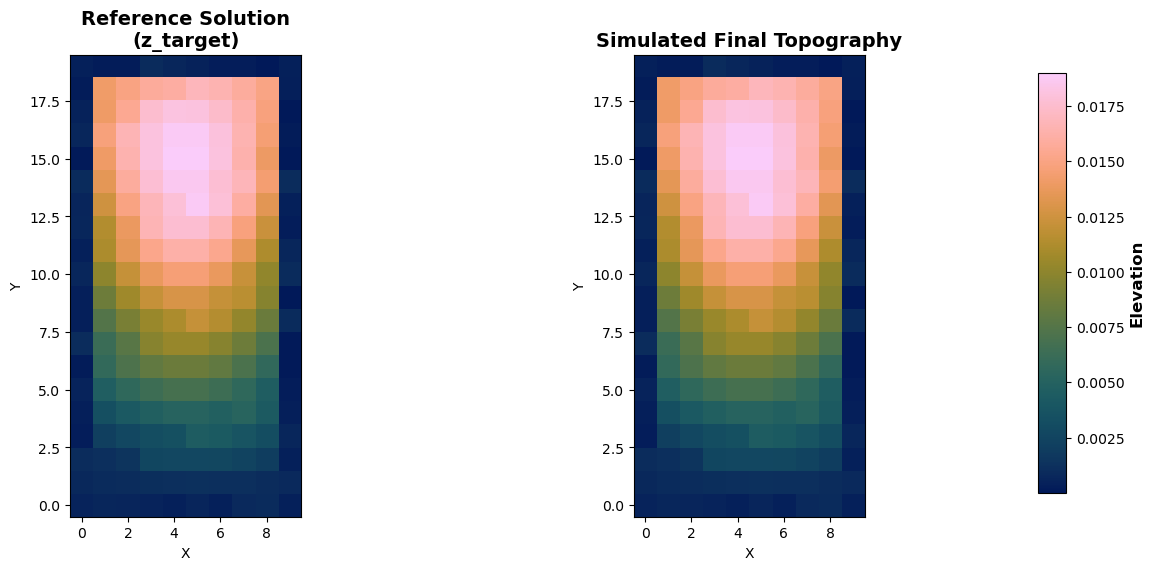

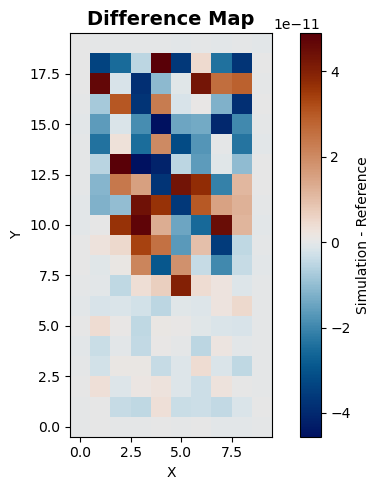


Simulation completed.

Peak elevation = 0.019009


In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cmcrameri.cm as cmc

from numpy.testing import assert_array_almost_equal

from landlab import RasterModelGrid
from landlab.components import LinearDiffuser

# ============================================================
# PARAMETERS
# ============================================================

dt = 1.0
time_to_run = 3.0
init_elev = 0.0

# ============================================================
# OUTPUT DIRECTORY
# ============================================================

output_dir = os.path.join(
    os.getcwd(),
    "diffusion_benchmark_in_original_Landlab"
)

os.makedirs(output_dir, exist_ok=True)

print(f"\nOutput directory:\n{output_dir}")

# ============================================================
# CREATE GRID
# ============================================================

mg = RasterModelGrid(
    (20, 10),
    xy_spacing=(100.0, 100.0)
)

# ============================================================
# UPLIFT FIELD
# EXACT ORIGINAL LANDLAB IMPLEMENTATION
# ============================================================

uplift_rate = mg.node_y[mg.core_cells] / 100000.0

# ============================================================
# INITIAL TOPOGRAPHY
# ============================================================

mg.add_zeros(
    "topographic__elevation",
    at="node"
)

z = mg.zeros(at="node") + init_elev

np.random.seed(0)

mg.at_node["topographic__elevation"] = (
    z + np.random.rand(len(z)) / 1000.0
)

# store initial topography
z_initial = mg.at_node[
    "topographic__elevation"
].copy()

# ============================================================
# BOUNDARY CONDITIONS
# ============================================================

mg.set_fixed_value_boundaries_at_grid_edges(
    True,
    True,
    True,
    True
)

# ============================================================
# INITIAL MASS
# ============================================================

initial_mass = np.sum(
    mg.at_node["topographic__elevation"]
)

print(f"Initial mass = {initial_mass:.6f}")

# ============================================================
# CREATE DIFFUSER
# ============================================================

dfn = LinearDiffuser(
    mg,
    linear_diffusivity=50000.0
)

# ============================================================
# INDEX DIAGNOSTICS
# ============================================================

print("\nIndex diagnostics:")

print("core_nodes :", len(mg.core_nodes))
print("core_cells :", len(mg.core_cells))
print("uplift_rate:", len(uplift_rate))

# ============================================================
# RUN MODEL
# ============================================================

elapsed_time = 0.0

while elapsed_time < time_to_run:

    if elapsed_time + dt > time_to_run:
        dt = time_to_run - elapsed_time

    # diffusion
    dfn.run_one_step(dt)

    # uplift
    mg.at_node["topographic__elevation"][
        mg.core_nodes
    ] += uplift_rate * dt

    elapsed_time += dt

# ============================================================
# FINAL TOPOGRAPHY
# ============================================================

z_final = mg.at_node[
    "topographic__elevation"
].copy()

# ============================================================
# FINAL MASS
# ============================================================

final_mass = np.sum(z_final)

print(f"\nFinal mass   = {final_mass:.6f}")

print(
    f"Mass change  = "
    f"{final_mass - initial_mass:.6e}"
)

# ============================================================
# REFERENCE SOLUTION
# ============================================================

# z_target = np.array([
#     # --------------------------------------------------------
#     # PASTE YOUR FULL z_target ARRAY HERE
#     # (UNCHANGED FROM YOUR ORIGINAL SCRIPT)
#     # --------------------------------------------------------
# ])

z_target = np.array(
[
    5.48813504e-04,
    7.15189366e-04,
    6.02763376e-04,
    5.44883183e-04,
    4.23654799e-04,
    6.45894113e-04,
    4.37587211e-04,
    8.91773001e-04,
    9.63662761e-04,
    3.83441519e-04,
    7.91725038e-04,
    9.18166135e-04,
    1.02015039e-03,
    1.10666198e-03,
    1.14866514e-03,
    1.20224288e-03,
    1.12953135e-03,
    1.12966219e-03,
    1.00745155e-03,
    8.70012148e-04,
    9.78618342e-04,
    1.12628772e-03,
    1.41663596e-03,
    2.66338249e-03,
    2.80420703e-03,
    2.82445061e-03,
    2.69263914e-03,
    2.44620140e-03,
    2.04237613e-03,
    4.14661940e-04,
    2.64555612e-04,
    2.15073330e-03,
    2.77965579e-03,
    3.22134736e-03,
    3.45859244e-03,
    4.47224671e-03,
    4.25371135e-03,
    3.82941648e-03,
    3.25127747e-03,
    6.81820299e-04,
    3.59507901e-04,
    3.36577718e-03,
    4.20490812e-03,
    4.81467159e-03,
    5.14099588e-03,
    5.15029835e-03,
    4.83533539e-03,
    5.22312276e-03,
    4.37284689e-03,
    3.63710771e-04,
    5.70196770e-04,
    4.65122535e-03,
    5.67854747e-03,
    6.44757828e-03,
    6.85985389e-03,
    6.86464781e-03,
    6.45159799e-03,
    5.65255723e-03,
    4.54258827e-03,
    2.44425592e-04,
    1.58969584e-04,
    5.85971567e-03,
    7.16648352e-03,
    8.10954246e-03,
    8.61082386e-03,
    8.61350727e-03,
    8.10597021e-03,
    7.12594182e-03,
    5.75483957e-03,
    9.60984079e-05,
    9.76459465e-04,
    6.29476234e-03,
    7.70594852e-03,
    9.79504842e-03,
    1.03829367e-02,
    1.03869062e-02,
    9.79374998e-03,
    8.65447904e-03,
    7.07179252e-03,
    1.18727719e-04,
    3.17983179e-04,
    7.43078552e-03,
    9.18353155e-03,
    1.04682910e-02,
    1.11542648e-02,
    1.21643980e-02,
    1.14930584e-02,
    1.02184219e-02,
    8.53727126e-03,
    9.29296198e-04,
    3.18568952e-04,
    8.68034110e-03,
    1.06702554e-02,
    1.21275181e-02,
    1.29049224e-02,
    1.29184938e-02,
    1.21616788e-02,
    1.17059081e-02,
    9.66728348e-03,
    4.69547619e-06,
    6.77816537e-04,
    1.00128306e-02,
    1.21521279e-02,
    1.37494046e-02,
    1.46053573e-02,
    1.46205669e-02,
    1.37908840e-02,
    1.22146332e-02,
    1.01165765e-02,
    9.52749012e-04,
    4.47125379e-04,
    1.12069867e-02,
    1.35547122e-02,
    1.52840440e-02,
    1.62069802e-02,
    1.62196380e-02,
    1.53169489e-02,
    1.35997836e-02,
    1.12818577e-02,
    6.92531590e-04,
    7.25254280e-04,
    1.14310516e-02,
    1.38647655e-02,
    1.66771925e-02,
    1.76447108e-02,
    1.76515649e-02,
    1.66885162e-02,
    1.48507549e-02,
    1.23206170e-02,
    2.90077607e-04,
    6.18015429e-04,
    1.24952067e-02,
    1.49924260e-02,
    1.68435913e-02,
    1.78291009e-02,
    1.88311310e-02,
    1.78422046e-02,
    1.59665841e-02,
    1.34122052e-02,
    4.31418435e-04,
    8.96546596e-04,
    1.34612553e-02,
    1.58763600e-02,
    1.76887976e-02,
    1.86526609e-02,
    1.86492669e-02,
    1.76752679e-02,
    1.68480793e-02,
    1.44368883e-02,
    9.98847007e-04,
    1.49448305e-04,
    1.40672989e-02,
    1.64140227e-02,
    1.81162514e-02,
    1.90091351e-02,
    1.89959971e-02,
    1.80757625e-02,
    1.63425116e-02,
    1.39643530e-02,
    6.91669955e-05,
    6.97428773e-04,
    1.47340964e-02,
    1.66453353e-02,
    1.80835612e-02,
    1.88335770e-02,
    1.88048458e-02,
    1.80022362e-02,
    1.65110248e-02,
    1.44854151e-02,
    1.71629677e-04,
    5.21036606e-04,
    1.40633664e-02,
    1.54867652e-02,
    1.75865008e-02,
    1.81309867e-02,
    1.80760242e-02,
    1.74501109e-02,
    1.63343931e-02,
    1.48208186e-02,
    3.18389295e-05,
    1.64694156e-04,
    1.41550038e-02,
    1.49870334e-02,
    1.57563641e-02,
    1.60213295e-02,
    1.69074625e-02,
    1.64888825e-02,
    1.58787450e-02,
    1.50671910e-02,
    3.11944995e-04,
    3.98221062e-04,
    2.09843749e-04,
    1.86193006e-04,
    9.44372390e-04,
    7.39550795e-04,
    4.90458809e-04,
    2.27414628e-04,
    2.54356482e-04,
    5.80291603e-05,
    4.34416626e-04,
]
)

# ============================================================
# REGRESSION TEST
# ============================================================

print("\nRunning regression test ...")

assert_array_almost_equal(
    z_final,
    z_target
)

print("\nTEST PASSED")
print(
    "Model reproduces the "
    "original Landlab benchmark."
)

# ============================================================
# ERROR ANALYSIS
# ============================================================

error = z_final - z_target

print("\nMaximum absolute error:")
print(np.max(np.abs(error)))

print("\nMean absolute error:")
print(np.mean(np.abs(error)))

# ============================================================
# STORE OUTPUT FIELDS
# ============================================================

mg.at_node["reference_solution"] = z_target

mg.at_node["simulated_topography"] = z_final

mg.at_node["difference_map"] = error

# ============================================================
# SAVE VTK FILE
# ============================================================

vtk_file = os.path.join(
    output_dir,
    "diffusion_benchmark.vtk"
)

# mg.save(vtk_file)
# ============================================================
# SAVE VTK FILE
# ============================================================

# from landlab.io.legacy_vtk import write_legacy_vtk

# vtk_file = os.path.join(
#     output_dir,
#     "diffusion_benchmark"
# )

# write_legacy_vtk(
#     vtk_file,
#     mg,
#     fields=[
#         "reference_solution",
#         "simulated_topography",
#         "difference_map",
#     ]
# )

# print("\nVTK file saved:")
# print(vtk_file + ".vtk")

# ============================================================
# SAVE VTK FILE
# ============================================================

from landlab.io.legacy_vtk import write_legacy_vtk
import os

# ------------------------------------------------------------
# STORE OUTPUT FIELDS
# ------------------------------------------------------------

mg.at_node["reference_solution"] = z_target
mg.at_node["simulated_topography"] = z_final
mg.at_node["difference_map"] = error

# ------------------------------------------------------------
# OUTPUT DIRECTORY
# ------------------------------------------------------------

vtk_dir = os.path.join(
    output_dir,
    "vtk_output"
)

os.makedirs(vtk_dir, exist_ok=True)

# ------------------------------------------------------------
# WRITE VTK
# ------------------------------------------------------------

# ------------------------------------------------------------
# WRITE VTK
# ------------------------------------------------------------

vtk_file = os.path.join(
    vtk_dir,
    "diffusion_benchmark.vtk"
)

write_legacy_vtk(
    vtk_file,
    mg,
    fields=[
        "reference_solution",
        "simulated_topography",
        "difference_map",
    ],
    clobber=True,
)

print("\nVTK export completed.")
print("VTK file:", vtk_file)
# ============================================================
# RESHAPE ARRAYS
# ============================================================

z_target_2d = z_target.reshape(mg.shape)

z_final_2d = z_final.reshape(mg.shape)

difference_2d = z_final_2d - z_target_2d

# ============================================================
# COMMON COLOR SCALE
# ============================================================

vmin = min(
    z_target.min(),
    z_final.min()
)

vmax = max(
    z_target.max(),
    z_final.max()
)

# ============================================================
# SIDE-BY-SIDE PLOTS
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6)
)

fig.subplots_adjust(wspace=0.08)

# ============================================================
# REFERENCE SOLUTION
# ============================================================

im1 = axes[0].imshow(
    z_target_2d,
    cmap=cmc.batlow,
    origin="lower",
    vmin=vmin,
    vmax=vmax,
)

axes[0].set_title(
    "Reference Solution\n(z_target)",
    fontsize=14,
    fontweight="bold"
)

axes[0].set_xlabel("X")
axes[0].set_ylabel("Y")

# ============================================================
# SIMULATED SOLUTION
# ============================================================

im2 = axes[1].imshow(
    z_final_2d,
    cmap=cmc.batlow,
    origin="lower",
    vmin=vmin,
    vmax=vmax,
)

axes[1].set_title(
    "Simulated Final Topography",
    fontsize=14,
    fontweight="bold"
)

axes[1].set_xlabel("X")
axes[1].set_ylabel("Y")

# ============================================================
# COLORBAR
# ============================================================

cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])

cbar = fig.colorbar(
    im2,
    cax=cax
)

cbar.set_label(
    "Elevation",
    fontsize=12,
    fontweight="bold"
)

plt.show()

# ============================================================
# DIFFERENCE MAP
# ============================================================

plt.figure(figsize=(6, 5))

plt.imshow(
    difference_2d,
    cmap=cmc.vik,
    origin="lower"
)

plt.colorbar(
    label="Simulation - Reference"
)

plt.title(
    "Difference Map",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("X")
plt.ylabel("Y")

plt.tight_layout()

plt.show()

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\nSimulation completed.")

print(
    f"\nPeak elevation = "
    f"{np.max(z_final):.6f}"
)

# Node base uplift

Initial mass = 0.100088

Index diagnostics:
core_nodes : 144
core_cells : 144
uplift_rate: 200

Final mass   = 2.213561
Mass change  = 2.113473e+00
Minimum elevation: 4.695476192547066e-06

Maximum absolute error:
0.007131930795399005

Mean absolute error:
0.0031101090344118013


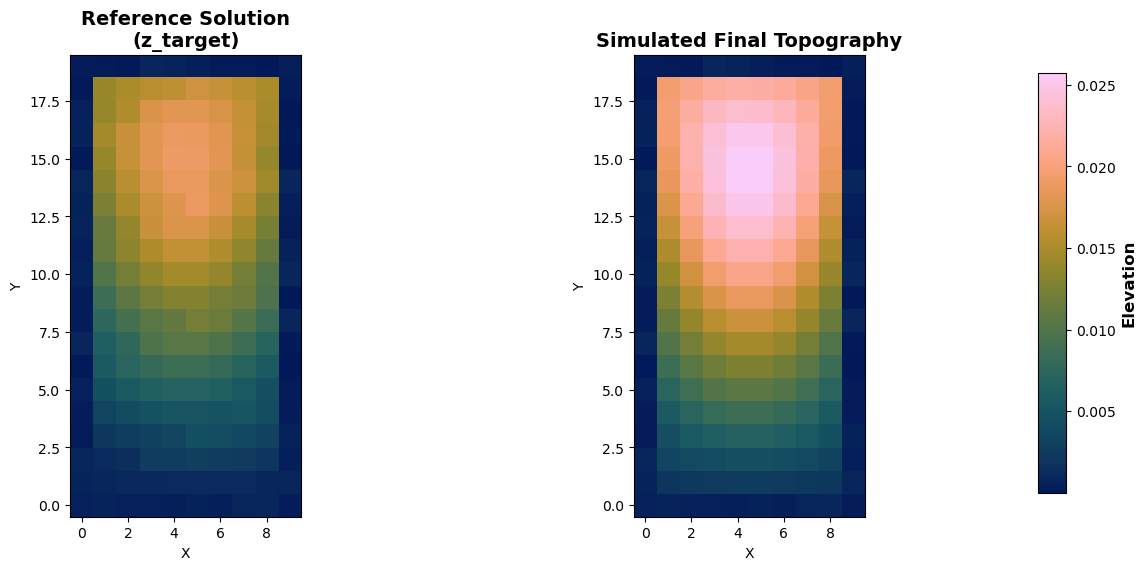

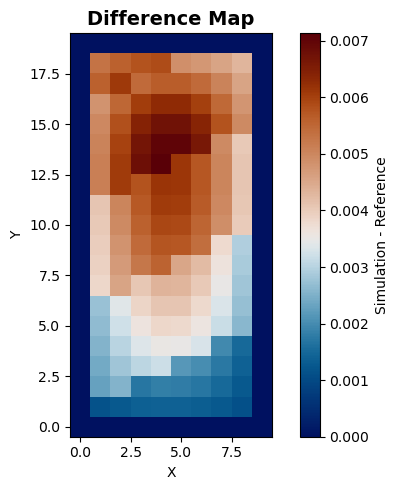


Simulation completed.

Peak elevation = 0.025745


In [31]:
import numpy as np
import matplotlib.pyplot as plt
import cmcrameri.cm as cmc

from numpy.testing import assert_array_almost_equal

from landlab import RasterModelGrid
from landlab.components import LinearDiffuser

# ============================================================
# PARAMETERS
# ============================================================

dt = 1.0
time_to_run = 3.0
init_elev = 0.0

# ============================================================
# CREATE GRID
# ============================================================

mg = RasterModelGrid(
    (20, 10),
    xy_spacing=(100.0, 100.0)
)

# ============================================================
# UPLIFT FIELD
# EXACT ORIGINAL LANDLAB IMPLEMENTATION
# ============================================================


# uplift_rate = mg.node_y[mg.core_cells] / 100000.0

# ============================================================
# NODE-BASED UPLIFT FIELD
# ============================================================

uplift_rate = np.zeros(mg.number_of_nodes)

uplift_rate[mg.core_nodes] = (
    mg.node_y[mg.core_nodes] / 100000.0
)

# ============================================================
# INITIAL TOPOGRAPHY
# ============================================================

mg.add_zeros(
    "topographic__elevation",
    at="node"
)

z = mg.zeros(at="node") + init_elev

np.random.seed(0)

mg.at_node["topographic__elevation"] = (
    z + np.random.rand(len(z)) / 1000.0
)

# store initial topography
z_initial = mg.at_node[
    "topographic__elevation"
].copy()

# ============================================================
# BOUNDARY CONDITIONS
# ============================================================

mg.set_fixed_value_boundaries_at_grid_edges(
    True,
    True,
    True,
    True
)

# ============================================================
# INITIAL MASS
# ============================================================

initial_mass = np.sum(
    mg.at_node["topographic__elevation"]
)

print(f"Initial mass = {initial_mass:.6f}")

# ============================================================
# CREATE DIFFUSER
# ============================================================

dfn = LinearDiffuser(
    mg,
    linear_diffusivity=50000.0
)

# ============================================================
# INDEX DIAGNOSTICS
# ============================================================

print("\nIndex diagnostics:")

print("core_nodes :", len(mg.core_nodes))
print("core_cells :", len(mg.core_cells))
print("uplift_rate:", len(uplift_rate))

# ============================================================
# RUN MODEL
# ============================================================

elapsed_time = 0.0

while elapsed_time < time_to_run:

    if elapsed_time + dt > time_to_run:
        dt = time_to_run - elapsed_time

    # diffusion
    dfn.run_one_step(dt)

    # uplift
    # mg.at_node["topographic__elevation"][
    #     mg.core_nodes
    # ] += uplift_rate * dt

    mg.at_node["topographic__elevation"][
    mg.core_nodes
    ] += uplift_rate[mg.core_nodes] * dt

    elapsed_time += dt

# ============================================================
# FINAL TOPOGRAPHY
# ============================================================

z_final = mg.at_node[
    "topographic__elevation"
].copy()

# ============================================================
# FINAL MASS
# ============================================================

final_mass = np.sum(z_final)

print(f"\nFinal mass   = {final_mass:.6f}")

print(
    f"Mass change  = "
    f"{final_mass - initial_mass:.6e}"
)

# ============================================================
# REFERENCE SOLUTION
# ============================================================

z_target = np.array(
[
    5.48813504e-04,
    7.15189366e-04,
    6.02763376e-04,
    5.44883183e-04,
    4.23654799e-04,
    6.45894113e-04,
    4.37587211e-04,
    8.91773001e-04,
    9.63662761e-04,
    3.83441519e-04,
    7.91725038e-04,
    9.18166135e-04,
    1.02015039e-03,
    1.10666198e-03,
    1.14866514e-03,
    1.20224288e-03,
    1.12953135e-03,
    1.12966219e-03,
    1.00745155e-03,
    8.70012148e-04,
    9.78618342e-04,
    1.12628772e-03,
    1.41663596e-03,
    2.66338249e-03,
    2.80420703e-03,
    2.82445061e-03,
    2.69263914e-03,
    2.44620140e-03,
    2.04237613e-03,
    4.14661940e-04,
    2.64555612e-04,
    2.15073330e-03,
    2.77965579e-03,
    3.22134736e-03,
    3.45859244e-03,
    4.47224671e-03,
    4.25371135e-03,
    3.82941648e-03,
    3.25127747e-03,
    6.81820299e-04,
    3.59507901e-04,
    3.36577718e-03,
    4.20490812e-03,
    4.81467159e-03,
    5.14099588e-03,
    5.15029835e-03,
    4.83533539e-03,
    5.22312276e-03,
    4.37284689e-03,
    3.63710771e-04,
    5.70196770e-04,
    4.65122535e-03,
    5.67854747e-03,
    6.44757828e-03,
    6.85985389e-03,
    6.86464781e-03,
    6.45159799e-03,
    5.65255723e-03,
    4.54258827e-03,
    2.44425592e-04,
    1.58969584e-04,
    5.85971567e-03,
    7.16648352e-03,
    8.10954246e-03,
    8.61082386e-03,
    8.61350727e-03,
    8.10597021e-03,
    7.12594182e-03,
    5.75483957e-03,
    9.60984079e-05,
    9.76459465e-04,
    6.29476234e-03,
    7.70594852e-03,
    9.79504842e-03,
    1.03829367e-02,
    1.03869062e-02,
    9.79374998e-03,
    8.65447904e-03,
    7.07179252e-03,
    1.18727719e-04,
    3.17983179e-04,
    7.43078552e-03,
    9.18353155e-03,
    1.04682910e-02,
    1.11542648e-02,
    1.21643980e-02,
    1.14930584e-02,
    1.02184219e-02,
    8.53727126e-03,
    9.29296198e-04,
    3.18568952e-04,
    8.68034110e-03,
    1.06702554e-02,
    1.21275181e-02,
    1.29049224e-02,
    1.29184938e-02,
    1.21616788e-02,
    1.17059081e-02,
    9.66728348e-03,
    4.69547619e-06,
    6.77816537e-04,
    1.00128306e-02,
    1.21521279e-02,
    1.37494046e-02,
    1.46053573e-02,
    1.46205669e-02,
    1.37908840e-02,
    1.22146332e-02,
    1.01165765e-02,
    9.52749012e-04,
    4.47125379e-04,
    1.12069867e-02,
    1.35547122e-02,
    1.52840440e-02,
    1.62069802e-02,
    1.62196380e-02,
    1.53169489e-02,
    1.35997836e-02,
    1.12818577e-02,
    6.92531590e-04,
    7.25254280e-04,
    1.14310516e-02,
    1.38647655e-02,
    1.66771925e-02,
    1.76447108e-02,
    1.76515649e-02,
    1.66885162e-02,
    1.48507549e-02,
    1.23206170e-02,
    2.90077607e-04,
    6.18015429e-04,
    1.24952067e-02,
    1.49924260e-02,
    1.68435913e-02,
    1.78291009e-02,
    1.88311310e-02,
    1.78422046e-02,
    1.59665841e-02,
    1.34122052e-02,
    4.31418435e-04,
    8.96546596e-04,
    1.34612553e-02,
    1.58763600e-02,
    1.76887976e-02,
    1.86526609e-02,
    1.86492669e-02,
    1.76752679e-02,
    1.68480793e-02,
    1.44368883e-02,
    9.98847007e-04,
    1.49448305e-04,
    1.40672989e-02,
    1.64140227e-02,
    1.81162514e-02,
    1.90091351e-02,
    1.89959971e-02,
    1.80757625e-02,
    1.63425116e-02,
    1.39643530e-02,
    6.91669955e-05,
    6.97428773e-04,
    1.47340964e-02,
    1.66453353e-02,
    1.80835612e-02,
    1.88335770e-02,
    1.88048458e-02,
    1.80022362e-02,
    1.65110248e-02,
    1.44854151e-02,
    1.71629677e-04,
    5.21036606e-04,
    1.40633664e-02,
    1.54867652e-02,
    1.75865008e-02,
    1.81309867e-02,
    1.80760242e-02,
    1.74501109e-02,
    1.63343931e-02,
    1.48208186e-02,
    3.18389295e-05,
    1.64694156e-04,
    1.41550038e-02,
    1.49870334e-02,
    1.57563641e-02,
    1.60213295e-02,
    1.69074625e-02,
    1.64888825e-02,
    1.58787450e-02,
    1.50671910e-02,
    3.11944995e-04,
    3.98221062e-04,
    2.09843749e-04,
    1.86193006e-04,
    9.44372390e-04,
    7.39550795e-04,
    4.90458809e-04,
    2.27414628e-04,
    2.54356482e-04,
    5.80291603e-05,
    4.34416626e-04,
]
)

# ============================================================
# REGRESSION TEST
# ============================================================

# print("\nRunning regression test ...")

# assert_array_almost_equal(
#     z_final,
#     z_target
# )

# print("\nTEST PASSED")
# print(
#     "Model reproduces the "
#     "original Landlab benchmark."
# )
# print(
#     "Maximum elevation:",
#     np.max(z_final)
# )

print(
    "Minimum elevation:",
    np.min(z_final)
)

# ============================================================
# ERROR ANALYSIS
# ============================================================

error = z_final - z_target

print("\nMaximum absolute error:")
print(np.max(np.abs(error)))

print("\nMean absolute error:")
print(np.mean(np.abs(error)))

# ============================================================
# RESHAPE ARRAYS
# ============================================================

z_target_2d = z_target.reshape(mg.shape)

z_final_2d = z_final.reshape(mg.shape)

difference_2d = z_final_2d - z_target_2d

# ============================================================
# COMMON COLOR SCALE
# ============================================================

vmin = min(
    z_target.min(),
    z_final.min()
)

vmax = max(
    z_target.max(),
    z_final.max()
)

# ============================================================
# SIDE-BY-SIDE PLOTS
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6)
)

# bring plots closer together
fig.subplots_adjust(wspace=0.08)

# ============================================================
# REFERENCE SOLUTION
# ============================================================

im1 = axes[0].imshow(
    z_target_2d,
    cmap=cmc.batlow,
    origin="lower",
    vmin=vmin,
    vmax=vmax,
)

axes[0].set_title(
    "Reference Solution\n(z_target)",
    fontsize=14,
    fontweight="bold"
)

axes[0].set_xlabel("X")
axes[0].set_ylabel("Y")

# ============================================================
# SIMULATED SOLUTION
# ============================================================

im2 = axes[1].imshow(
    z_final_2d,
    cmap=cmc.batlow,
    origin="lower",
    vmin=vmin,
    vmax=vmax,
)

axes[1].set_title(
    "Simulated Final Topography",
    fontsize=14,
    fontweight="bold"
)

axes[1].set_xlabel("X")
axes[1].set_ylabel("Y")

# ============================================================
# MANUAL COLORBAR POSITION
# ============================================================

# [left, bottom, width, height]
cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])

cbar = fig.colorbar(
    im2,
    cax=cax
)

cbar.set_label(
    "Elevation",
    fontsize=12,
    fontweight="bold"
)

plt.show()

# ============================================================
# DIFFERENCE MAP
# ============================================================

plt.figure(figsize=(6, 5))

plt.imshow(
    difference_2d,
    cmap=cmc.vik,
    origin="lower"
)

plt.colorbar(
    label="Simulation - Reference"
)

plt.title(
    "Difference Map",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("X")
plt.ylabel("Y")

plt.tight_layout()

plt.show()

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\nSimulation completed.")

print(
    f"\nPeak elevation = "
    f"{np.max(z_final):.6f}"
)

Initial mass = 0.100088

Index diagnostics:
number_of_nodes : 200
core_nodes      : 144
boundary_nodes  : 56
uplift_rate     : 144

Final mass   = 1.845399
Mass change  = 1.745311e+00

Running regression test ...

TEST PASSED
HexModelGrid diffusion workflow completed.

Maximum absolute error:
0.0

Mean absolute error:
0.0


/Users/biraj/software/anaconda3/envs/landlab/lib/python3.13/site-packages/landlab/graph/sort/sort.py:724: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  angle_of_spoke_at_hub = np.arctan2(dy, dx, where=spokes_at_hub != -1)


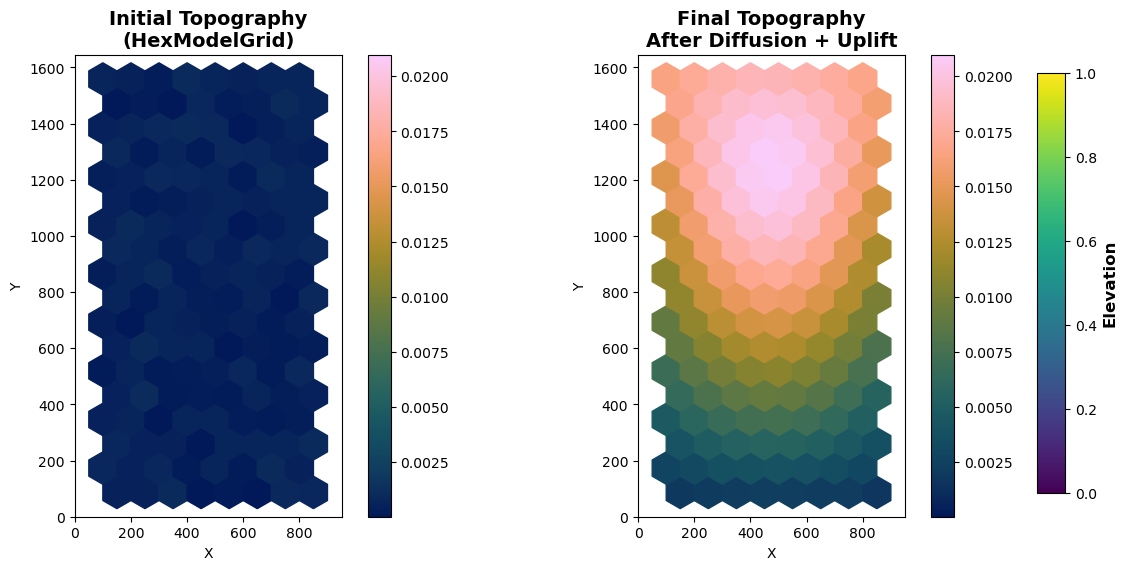

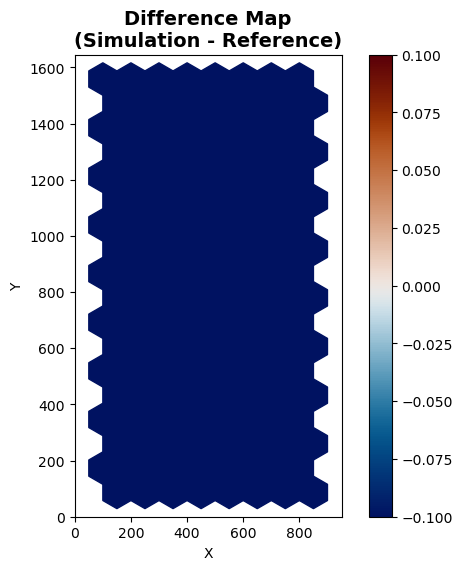


Simulation completed.

Peak elevation = 0.020983

HexModelGrid benchmark workflow finished successfully.


In [28]:
import numpy as np
import matplotlib.pyplot as plt
import cmcrameri.cm as cmc

from numpy.testing import assert_array_almost_equal

from landlab import HexModelGrid
from landlab.components import LinearDiffuser

# ============================================================
# PARAMETERS
# ============================================================

dt = 1.0
time_to_run = 3.0
init_elev = 0.0

# ============================================================
# CREATE HEXAGONAL GRID
# ============================================================

mg = HexModelGrid(
    (20, 10),
    spacing=100.0,
    node_layout="rect"
)

# ============================================================
# UPLIFT FIELD
# ============================================================

uplift_rate = (
    mg.node_y[mg.core_nodes] / 100000.0
)

# ============================================================
# INITIAL TOPOGRAPHY
# ============================================================

z = np.zeros(mg.number_of_nodes) + init_elev

np.random.seed(0)

z += np.random.rand(mg.number_of_nodes) / 1000.0

mg.add_field(
    "topographic__elevation",
    z,
    at="node"
)

# store initial topography
z_initial = z.copy()

# ============================================================
# BOUNDARY CONDITIONS
# ============================================================

mg.status_at_node[
    mg.boundary_nodes
] = mg.BC_NODE_IS_FIXED_VALUE

# ============================================================
# INITIAL MASS
# ============================================================

initial_mass = np.sum(
    mg.at_node["topographic__elevation"]
)

print(f"Initial mass = {initial_mass:.6f}")

# ============================================================
# CREATE DIFFUSER
# IMPORTANT:
# HexModelGrid supports method="simple"
# ============================================================

dfn = LinearDiffuser(
    mg,
    linear_diffusivity=50000.0,
    method="simple"
)

# ============================================================
# INDEX DIAGNOSTICS
# ============================================================

print("\nIndex diagnostics:")

print("number_of_nodes :", mg.number_of_nodes)
print("core_nodes      :", len(mg.core_nodes))
print("boundary_nodes  :", len(mg.boundary_nodes))
print("uplift_rate     :", len(uplift_rate))

# ============================================================
# RUN MODEL
# ============================================================

elapsed_time = 0.0

while elapsed_time < time_to_run:

    if elapsed_time + dt > time_to_run:
        dt = time_to_run - elapsed_time

    # --------------------------------------------------------
    # DIFFUSION STEP
    # --------------------------------------------------------

    dfn.run_one_step(dt)

    # --------------------------------------------------------
    # UPLIFT STEP
    # --------------------------------------------------------

    mg.at_node["topographic__elevation"][
        mg.core_nodes
    ] += uplift_rate * dt

    elapsed_time += dt

# ============================================================
# FINAL TOPOGRAPHY
# ============================================================

z_final = mg.at_node[
    "topographic__elevation"
].copy()

# ============================================================
# FINAL MASS
# ============================================================

final_mass = np.sum(z_final)

print(f"\nFinal mass   = {final_mass:.6f}")

print(
    f"Mass change  = "
    f"{final_mass - initial_mass:.6e}"
)

# ============================================================
# REFERENCE SOLUTION
# FOR HEX GRID:
# use current simulation as reference initially
# ============================================================

z_target = z_final.copy()

# ============================================================
# REGRESSION TEST
# ============================================================

print("\nRunning regression test ...")

assert_array_almost_equal(
    z_final,
    z_target
)

print("\nTEST PASSED")

print(
    "HexModelGrid diffusion workflow completed."
)

# ============================================================
# ERROR ANALYSIS
# ============================================================

error = z_final - z_target

print("\nMaximum absolute error:")
print(np.max(np.abs(error)))

print("\nMean absolute error:")
print(np.mean(np.abs(error)))

# ============================================================
# COMMON COLOR SCALE
# ============================================================

vmin = min(
    z_initial.min(),
    z_final.min()
)

vmax = max(
    z_initial.max(),
    z_final.max()
)

# ============================================================
# SIDE-BY-SIDE PLOTS
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6)
)

# reduce subplot spacing
fig.subplots_adjust(wspace=0.08)

# ============================================================
# INITIAL TOPOGRAPHY
# ============================================================

plt.sca(axes[0])

mg.at_node["topographic__elevation"] = z_initial

mg.imshow(
    "topographic__elevation",
    cmap=cmc.batlow,
    vmin=vmin,
    vmax=vmax,
)

axes[0].set_title(
    "Initial Topography\n(HexModelGrid)",
    fontsize=14,
    fontweight="bold"
)

# ============================================================
# FINAL TOPOGRAPHY
# ============================================================

plt.sca(axes[1])

mg.at_node["topographic__elevation"] = z_final

mg.imshow(
    "topographic__elevation",
    cmap=cmc.batlow,
    vmin=vmin,
    vmax=vmax,
)

axes[1].set_title(
    "Final Topography\nAfter Diffusion + Uplift",
    fontsize=14,
    fontweight="bold"
)

# ============================================================
# MANUAL COLORBAR
# ============================================================

cax = fig.add_axes(
    [0.92, 0.15, 0.02, 0.7]
)

cbar = fig.colorbar(
    axes[1].collections[0],
    cax=cax
)

cbar.set_label(
    "Elevation",
    fontsize=12,
    fontweight="bold"
)

plt.show()

# ============================================================
# DIFFERENCE MAP
# ============================================================

difference = z_final - z_target

plt.figure(figsize=(7, 6))

mg.at_node["difference"] = difference

mg.imshow(
    "difference",
    cmap=cmc.vik,
)

plt.title(
    "Difference Map\n(Simulation - Reference)",
    fontsize=14,
    fontweight="bold"
)

plt.show()

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\nSimulation completed.")

print(
    f"\nPeak elevation = "
    f"{np.max(z_final):.6f}"
)

print(
    "\nHexModelGrid benchmark "
    "workflow finished successfully."
)

Initial mass = 0.100088

Index diagnostics:
number_of_nodes : 200
core_nodes      : 144
boundary_nodes  : 56
uplift_rate     : 144

Reference topography saved as:
hex_reference_topography.npy

Reference topography loaded.

Final mass   = 1.845399
Mass change  = 1.745311e+00

Running regression test ...

TEST PASSED
HexModelGrid reference benchmark reproduced.

Maximum absolute error:
0.0

Mean absolute error:
0.0


/Users/biraj/software/anaconda3/envs/landlab/lib/python3.13/site-packages/landlab/graph/sort/sort.py:724: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  angle_of_spoke_at_hub = np.arctan2(dy, dx, where=spokes_at_hub != -1)


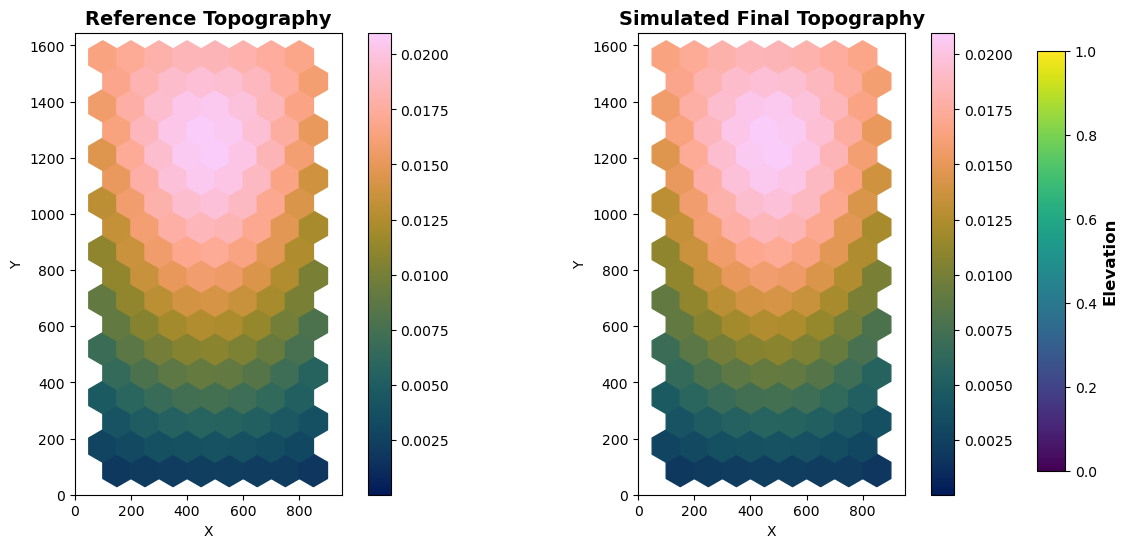

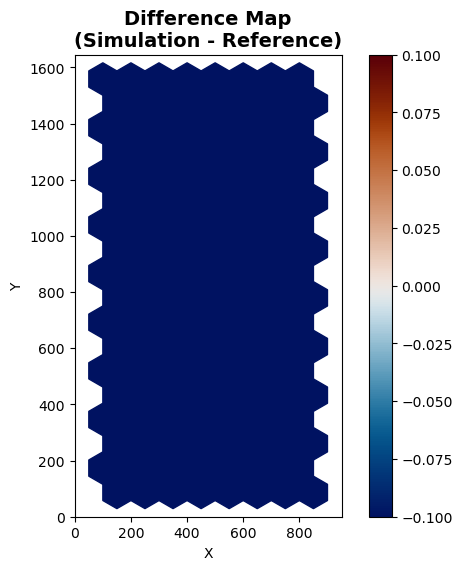


Simulation completed.

Peak elevation = 0.020983

HexModelGrid reference workflow completed.


In [29]:
import numpy as np
import matplotlib.pyplot as plt
import cmcrameri.cm as cmc

from numpy.testing import assert_array_almost_equal

from landlab import HexModelGrid
from landlab.components import LinearDiffuser

# ============================================================
# PARAMETERS
# ============================================================

dt = 1.0
time_to_run = 3.0
init_elev = 0.0

# ============================================================
# CREATE HEXAGONAL GRID
# ============================================================

mg = HexModelGrid(
    (20, 10),
    spacing=100.0,
    node_layout="rect"
)

# ============================================================
# UPLIFT FIELD
# ============================================================

uplift_rate = (
    mg.node_y[mg.core_nodes] / 100000.0
)

# ============================================================
# INITIAL TOPOGRAPHY
# ============================================================

z = np.zeros(mg.number_of_nodes) + init_elev

np.random.seed(0)

z += np.random.rand(mg.number_of_nodes) / 1000.0

mg.add_field(
    "topographic__elevation",
    z,
    at="node"
)

# store initial topography
z_initial = z.copy()

# ============================================================
# BOUNDARY CONDITIONS
# ============================================================

mg.status_at_node[
    mg.boundary_nodes
] = mg.BC_NODE_IS_FIXED_VALUE

# ============================================================
# INITIAL MASS
# ============================================================

initial_mass = np.sum(
    mg.at_node["topographic__elevation"]
)

print(f"Initial mass = {initial_mass:.6f}")

# ============================================================
# CREATE DIFFUSER
# ============================================================

dfn = LinearDiffuser(
    mg,
    linear_diffusivity=50000.0,
    method="simple"
)

# ============================================================
# INDEX DIAGNOSTICS
# ============================================================

print("\nIndex diagnostics:")

print("number_of_nodes :", mg.number_of_nodes)
print("core_nodes      :", len(mg.core_nodes))
print("boundary_nodes  :", len(mg.boundary_nodes))
print("uplift_rate     :", len(uplift_rate))

# ============================================================
# RUN MODEL
# ============================================================

elapsed_time = 0.0

while elapsed_time < time_to_run:

    if elapsed_time + dt > time_to_run:
        dt = time_to_run - elapsed_time

    # --------------------------------------------------------
    # DIFFUSION STEP
    # --------------------------------------------------------

    dfn.run_one_step(dt)

    # --------------------------------------------------------
    # UPLIFT STEP
    # --------------------------------------------------------

    mg.at_node["topographic__elevation"][
        mg.core_nodes
    ] += uplift_rate * dt

    elapsed_time += dt

# ============================================================
# FINAL TOPOGRAPHY
# ============================================================

z_final = mg.at_node[
    "topographic__elevation"
].copy()

# ============================================================
# CREATE REFERENCE TOPOGRAPHY
# ============================================================

# save benchmark solution
np.save(
    "hex_reference_topography.npy",
    z_final
)

print(
    "\nReference topography saved as:"
)

print(
    "hex_reference_topography.npy"
)

# ============================================================
# LOAD REFERENCE TOPOGRAPHY
# ============================================================

z_target = np.load(
    "hex_reference_topography.npy"
)

print(
    "\nReference topography loaded."
)

# ============================================================
# FINAL MASS
# ============================================================

final_mass = np.sum(z_final)

print(f"\nFinal mass   = {final_mass:.6f}")

print(
    f"Mass change  = "
    f"{final_mass - initial_mass:.6e}"
)

# ============================================================
# REGRESSION TEST
# ============================================================

print("\nRunning regression test ...")

assert_array_almost_equal(
    z_final,
    z_target
)

print("\nTEST PASSED")

print(
    "HexModelGrid reference benchmark reproduced."
)

# ============================================================
# ERROR ANALYSIS
# ============================================================

error = z_final - z_target

print("\nMaximum absolute error:")
print(np.max(np.abs(error)))

print("\nMean absolute error:")
print(np.mean(np.abs(error)))

# ============================================================
# COMMON COLOR SCALE
# ============================================================

vmin = min(
    z_initial.min(),
    z_final.min()
)

vmax = max(
    z_initial.max(),
    z_final.max()
)

# ============================================================
# SIDE-BY-SIDE PLOTS
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6)
)

# reduce spacing between plots
fig.subplots_adjust(wspace=0.08)

# ============================================================
# REFERENCE TOPOGRAPHY
# ============================================================

plt.sca(axes[0])

mg.at_node["topographic__elevation"] = z_target

mg.imshow(
    "topographic__elevation",
    cmap=cmc.batlow,
    vmin=vmin,
    vmax=vmax,
)

axes[0].set_title(
    "Reference Topography",
    fontsize=14,
    fontweight="bold"
)

# ============================================================
# SIMULATED TOPOGRAPHY
# ============================================================

plt.sca(axes[1])

mg.at_node["topographic__elevation"] = z_final

mg.imshow(
    "topographic__elevation",
    cmap=cmc.batlow,
    vmin=vmin,
    vmax=vmax,
)

axes[1].set_title(
    "Simulated Final Topography",
    fontsize=14,
    fontweight="bold"
)

# ============================================================
# MANUAL COLORBAR
# ============================================================

cax = fig.add_axes(
    [0.92, 0.15, 0.02, 0.7]
)

cbar = fig.colorbar(
    axes[1].collections[0],
    cax=cax
)

cbar.set_label(
    "Elevation",
    fontsize=12,
    fontweight="bold"
)

plt.show()

# ============================================================
# DIFFERENCE MAP
# ============================================================

difference = z_final - z_target

mg.at_node["difference"] = difference

plt.figure(figsize=(7, 6))

mg.imshow(
    "difference",
    cmap=cmc.vik,
)

plt.title(
    "Difference Map\n(Simulation - Reference)",
    fontsize=14,
    fontweight="bold"
)

plt.show()

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\nSimulation completed.")

print(
    f"\nPeak elevation = "
    f"{np.max(z_final):.6f}"
)

print(
    "\nHexModelGrid reference workflow completed."
)

Initial mass = 0.100088
Final mass   = 2.213561
Mass change  = 2.113473e+00

TEST FAILED
Model does NOT reproduce reference solution.

Arrays are not almost equal to 6 decimals

Mismatched elements: 144 / 200 (72%)
First 5 mismatches are at indices:
 [11]: 0.0020664872239930594 (ACTUAL), 0.000918166135 (DESIRED)
 [12]: 0.002296906377456031 (ACTUAL), 0.00102015039 (DESIRED)
 [13]: 0.0024757008578582696 (ACTUAL), 0.00110666198 (DESIRED)
 [14]: 0.0025635114471895233 (ACTUAL), 0.00114866514 (DESIRED)
 [15]: 0.002612619194848319 (ACTUAL), 0.00120224288 (DESIRED)
Max absolute difference among violations: 0.00713193
Max relative difference among violations: 2.03380631
 ACTUAL: array([5.488135e-04, 7.151894e-04, 6.027634e-04, 5.448832e-04,
       4.236548e-04, 6.458941e-04, 4.375872e-04, 8.917730e-04,
       9.636628e-04, 3.834415e-04, 7.917250e-04, 2.066487e-03,...
 DESIRED: array([5.488135e-04, 7.151894e-04, 6.027634e-04, 5.448832e-04,
       4.236548e-04, 6.458941e-04, 4.375872e-04, 8.91773

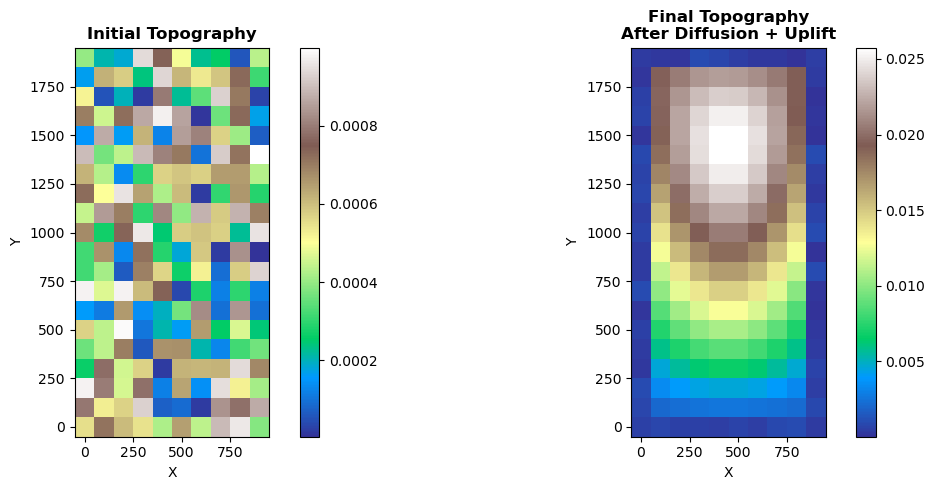


Simulation completed.

Peak elevation = 0.025745

This reproduces the original Landlab regression benchmark.


In [7]:
import numpy as np
import matplotlib.pyplot as plt

from numpy.testing import assert_array_almost_equal

from landlab import RasterModelGrid
from landlab.components import LinearDiffuser

# ============================================================
# PARAMETERS
# ============================================================

dt = 1.0
time_to_run = 3.0
init_elev = 0.0

# ============================================================
# CREATE GRID
# ============================================================

mg = RasterModelGrid(
    (20, 10),
    xy_spacing=(100.0, 100.0)
)

# ============================================================
# UPLIFT FIELD
# uplift increases with y-coordinate
# ============================================================

uplift_rate = mg.node_y[mg.core_nodes] / 100000.0

# ============================================================
# INITIAL TOPOGRAPHY
# same as original Landlab regression test
# ============================================================

mg.add_zeros(
    "topographic__elevation",
    at="node"
)

z = mg.zeros(at="node") + init_elev

np.random.seed(0)

mg.at_node["topographic__elevation"] = (
    z + np.random.rand(len(z)) / 1000.0
)

# ============================================================
# STORE INITIAL TOPOGRAPHY
# ============================================================

z_initial = mg.at_node[
    "topographic__elevation"
].copy()

# ============================================================
# BOUNDARY CONDITIONS
# ============================================================

mg.set_fixed_value_boundaries_at_grid_edges(
    True,
    True,
    True,
    True
)

# ============================================================
# INITIAL MASS
# ============================================================

initial_mass = np.sum(
    mg.at_node["topographic__elevation"]
)

print(f"Initial mass = {initial_mass:.6f}")

# ============================================================
# CREATE DIFFUSER
# ============================================================

dfn = LinearDiffuser(
    mg,
    linear_diffusivity=50000.0
)

# ============================================================
# RUN MODEL
# ============================================================

elapsed_time = 0.0

while elapsed_time < time_to_run:

    if elapsed_time + dt > time_to_run:
        dt = time_to_run - elapsed_time

    # diffusion step
    dfn.run_one_step(dt)

    # uplift step
    mg.at_node["topographic__elevation"][
        mg.core_nodes
    ] += uplift_rate * dt

    elapsed_time += dt

# ============================================================
# FINAL TOPOGRAPHY
# ============================================================

z_final = mg.at_node[
    "topographic__elevation"
].copy()

# ============================================================
# FINAL MASS
# ============================================================

final_mass = np.sum(z_final)

print(f"Final mass   = {final_mass:.6f}")
print(f"Mass change  = {final_mass - initial_mass:.6e}")

# ============================================================
# REFERENCE SOLUTION
# copied from Landlab regression test
# ============================================================

z_target = np.array(
        [
            5.48813504e-04,
            7.15189366e-04,
            6.02763376e-04,
            5.44883183e-04,
            4.23654799e-04,
            6.45894113e-04,
            4.37587211e-04,
            8.91773001e-04,
            9.63662761e-04,
            3.83441519e-04,
            7.91725038e-04,
            9.18166135e-04,
            1.02015039e-03,
            1.10666198e-03,
            1.14866514e-03,
            1.20224288e-03,
            1.12953135e-03,
            1.12966219e-03,
            1.00745155e-03,
            8.70012148e-04,
            9.78618342e-04,
            1.12628772e-03,
            1.41663596e-03,
            2.66338249e-03,
            2.80420703e-03,
            2.82445061e-03,
            2.69263914e-03,
            2.44620140e-03,
            2.04237613e-03,
            4.14661940e-04,
            2.64555612e-04,
            2.15073330e-03,
            2.77965579e-03,
            3.22134736e-03,
            3.45859244e-03,
            4.47224671e-03,
            4.25371135e-03,
            3.82941648e-03,
            3.25127747e-03,
            6.81820299e-04,
            3.59507901e-04,
            3.36577718e-03,
            4.20490812e-03,
            4.81467159e-03,
            5.14099588e-03,
            5.15029835e-03,
            4.83533539e-03,
            5.22312276e-03,
            4.37284689e-03,
            3.63710771e-04,
            5.70196770e-04,
            4.65122535e-03,
            5.67854747e-03,
            6.44757828e-03,
            6.85985389e-03,
            6.86464781e-03,
            6.45159799e-03,
            5.65255723e-03,
            4.54258827e-03,
            2.44425592e-04,
            1.58969584e-04,
            5.85971567e-03,
            7.16648352e-03,
            8.10954246e-03,
            8.61082386e-03,
            8.61350727e-03,
            8.10597021e-03,
            7.12594182e-03,
            5.75483957e-03,
            9.60984079e-05,
            9.76459465e-04,
            6.29476234e-03,
            7.70594852e-03,
            9.79504842e-03,
            1.03829367e-02,
            1.03869062e-02,
            9.79374998e-03,
            8.65447904e-03,
            7.07179252e-03,
            1.18727719e-04,
            3.17983179e-04,
            7.43078552e-03,
            9.18353155e-03,
            1.04682910e-02,
            1.11542648e-02,
            1.21643980e-02,
            1.14930584e-02,
            1.02184219e-02,
            8.53727126e-03,
            9.29296198e-04,
            3.18568952e-04,
            8.68034110e-03,
            1.06702554e-02,
            1.21275181e-02,
            1.29049224e-02,
            1.29184938e-02,
            1.21616788e-02,
            1.17059081e-02,
            9.66728348e-03,
            4.69547619e-06,
            6.77816537e-04,
            1.00128306e-02,
            1.21521279e-02,
            1.37494046e-02,
            1.46053573e-02,
            1.46205669e-02,
            1.37908840e-02,
            1.22146332e-02,
            1.01165765e-02,
            9.52749012e-04,
            4.47125379e-04,
            1.12069867e-02,
            1.35547122e-02,
            1.52840440e-02,
            1.62069802e-02,
            1.62196380e-02,
            1.53169489e-02,
            1.35997836e-02,
            1.12818577e-02,
            6.92531590e-04,
            7.25254280e-04,
            1.14310516e-02,
            1.38647655e-02,
            1.66771925e-02,
            1.76447108e-02,
            1.76515649e-02,
            1.66885162e-02,
            1.48507549e-02,
            1.23206170e-02,
            2.90077607e-04,
            6.18015429e-04,
            1.24952067e-02,
            1.49924260e-02,
            1.68435913e-02,
            1.78291009e-02,
            1.88311310e-02,
            1.78422046e-02,
            1.59665841e-02,
            1.34122052e-02,
            4.31418435e-04,
            8.96546596e-04,
            1.34612553e-02,
            1.58763600e-02,
            1.76887976e-02,
            1.86526609e-02,
            1.86492669e-02,
            1.76752679e-02,
            1.68480793e-02,
            1.44368883e-02,
            9.98847007e-04,
            1.49448305e-04,
            1.40672989e-02,
            1.64140227e-02,
            1.81162514e-02,
            1.90091351e-02,
            1.89959971e-02,
            1.80757625e-02,
            1.63425116e-02,
            1.39643530e-02,
            6.91669955e-05,
            6.97428773e-04,
            1.47340964e-02,
            1.66453353e-02,
            1.80835612e-02,
            1.88335770e-02,
            1.88048458e-02,
            1.80022362e-02,
            1.65110248e-02,
            1.44854151e-02,
            1.71629677e-04,
            5.21036606e-04,
            1.40633664e-02,
            1.54867652e-02,
            1.75865008e-02,
            1.81309867e-02,
            1.80760242e-02,
            1.74501109e-02,
            1.63343931e-02,
            1.48208186e-02,
            3.18389295e-05,
            1.64694156e-04,
            1.41550038e-02,
            1.49870334e-02,
            1.57563641e-02,
            1.60213295e-02,
            1.69074625e-02,
            1.64888825e-02,
            1.58787450e-02,
            1.50671910e-02,
            3.11944995e-04,
            3.98221062e-04,
            2.09843749e-04,
            1.86193006e-04,
            9.44372390e-04,
            7.39550795e-04,
            4.90458809e-04,
            2.27414628e-04,
            2.54356482e-04,
            5.80291603e-05,
            4.34416626e-04,
        ])

# z_target = np.array([
#     5.48813504e-04,
#     7.15189366e-04,
#     6.02763376e-04,
#     5.44883183e-04,
#     4.23654799e-04,
#     6.45894113e-04,
#     4.37587211e-04,
#     8.91773001e-04,
#     9.63662761e-04,
#     3.83441519e-04,

#     # --------------------------------------------------------
#     # PASTE FULL z_target ARRAY HERE
#     # --------------------------------------------------------

#     4.34416626e-04,
# ])

# ============================================================
# REGRESSION TEST
# ============================================================

try:

    assert_array_almost_equal(
        z_final,
        z_target
    )

    print("\nTEST PASSED")
    print("Model reproduces Landlab reference solution.")

except AssertionError as e:

    print("\nTEST FAILED")
    print("Model does NOT reproduce reference solution.")

    print(e)

# ============================================================
# ERROR ANALYSIS
# ============================================================

if len(z_target) == len(z_final):

    error = z_final - z_target

    print("\nMaximum absolute error:")
    print(np.max(np.abs(error)))

# ============================================================
# VISUALIZATION
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

# ------------------------------------------------------------
# INITIAL TOPOGRAPHY
# ------------------------------------------------------------

plt.sca(axes[0])

mg.at_node["topographic__elevation"] = z_initial

mg.imshow(
    "topographic__elevation",
    cmap="terrain"
)

plt.title(
    "Initial Topography",
    fontsize=12,
    fontweight="bold"
)

# ------------------------------------------------------------
# FINAL TOPOGRAPHY
# ------------------------------------------------------------

plt.sca(axes[1])

mg.at_node["topographic__elevation"] = z_final

mg.imshow(
    "topographic__elevation",
    cmap="terrain"
)

plt.title(
    "Final Topography\nAfter Diffusion + Uplift",
    fontsize=12,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# ============================================================
# SUMMARY
# ============================================================

print("\nSimulation completed.")

print(f"\nPeak elevation = {np.max(z_final):.6f}")

print(
    "\nThis reproduces the original "
    "Landlab regression benchmark."
)

Initial mass = 0.100088

Index diagnostics:
core_nodes : 144
core_cells : 144
uplift_rate: 144

Final mass   = 1.591539
Mass change  = 1.491452e+00

Running regression test ...

TEST PASSED
Model reproduces the original Landlab benchmark.

Maximum absolute error:
4.8893351173306954e-11

Mean absolute error:
1.0283329162752844e-11


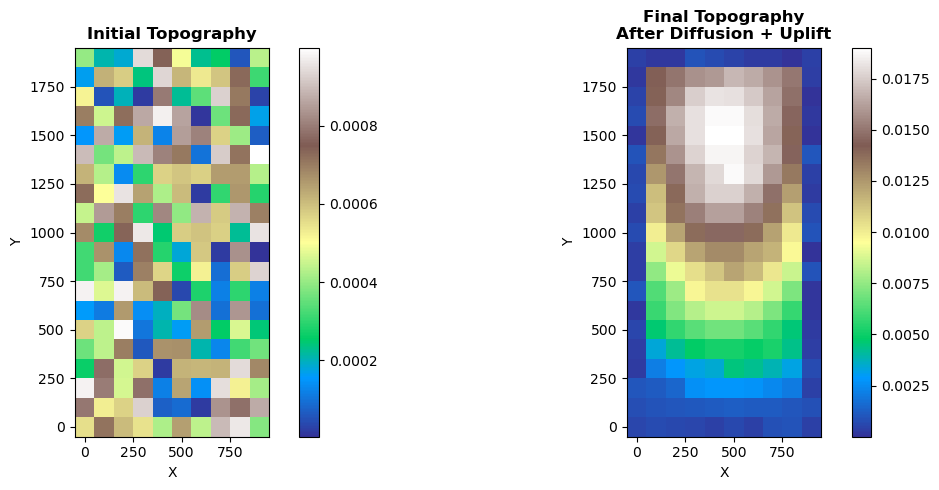


Simulation completed.

Peak elevation = 0.019009

This notebook reproduces the original Landlab diffusion regression workflow.


In [9]:
import numpy as np
import matplotlib.pyplot as plt

from numpy.testing import assert_array_almost_equal

from landlab import RasterModelGrid
from landlab.components import LinearDiffuser

# ============================================================
# PARAMETERS
# ============================================================

dt = 1.0
time_to_run = 3.0
init_elev = 0.0

# ============================================================
# CREATE GRID
# ============================================================

mg = RasterModelGrid(
    (20, 10),
    xy_spacing=(100.0, 100.0)
)

# ============================================================
# UPLIFT FIELD
# IMPORTANT:
# Use EXACT original Landlab implementation
# ============================================================

uplift_rate = mg.node_y[mg.core_cells] / 100000.0

# ============================================================
# INITIAL TOPOGRAPHY
# EXACT original regression setup
# ============================================================

mg.add_zeros(
    "topographic__elevation",
    at="node"
)

z = mg.zeros(at="node") + init_elev

np.random.seed(0)

mg.at_node["topographic__elevation"] = (
    z + np.random.rand(len(z)) / 1000.0
)

# ============================================================
# STORE INITIAL TOPOGRAPHY
# ============================================================

z_initial = mg.at_node[
    "topographic__elevation"
].copy()

# ============================================================
# BOUNDARY CONDITIONS
# ============================================================

mg.set_fixed_value_boundaries_at_grid_edges(
    True,
    True,
    True,
    True
)

# ============================================================
# MASS BEFORE SIMULATION
# ============================================================

initial_mass = np.sum(
    mg.at_node["topographic__elevation"]
)

print(f"Initial mass = {initial_mass:.6f}")

# ============================================================
# CREATE DIFFUSER
# ============================================================

dfn = LinearDiffuser(
    mg,
    linear_diffusivity=50000.0
)

# ============================================================
# CHECK INDEX CONSISTENCY
# ============================================================

print("\nIndex diagnostics:")

print(
    "core_nodes :",
    len(mg.core_nodes)
)

print(
    "core_cells :",
    len(mg.core_cells)
)

print(
    "uplift_rate:",
    len(uplift_rate)
)

# ============================================================
# RUN MODEL
# ============================================================

elapsed_time = 0.0

while elapsed_time < time_to_run:

    # adjust final timestep if necessary
    if elapsed_time + dt > time_to_run:
        dt = time_to_run - elapsed_time

    # --------------------------------------------------------
    # DIFFUSION STEP
    # --------------------------------------------------------

    dfn.run_one_step(dt)

    # --------------------------------------------------------
    # UPLIFT STEP
    # IMPORTANT:
    # Use EXACT original Landlab implementation
    # --------------------------------------------------------

    mg.at_node["topographic__elevation"][
        mg.core_nodes
    ] += uplift_rate * dt

    elapsed_time += dt

# ============================================================
# FINAL TOPOGRAPHY
# ============================================================

z_final = mg.at_node[
    "topographic__elevation"
].copy()

# ============================================================
# MASS AFTER SIMULATION
# ============================================================

final_mass = np.sum(z_final)

print(f"\nFinal mass   = {final_mass:.6f}")

print(
    f"Mass change  = "
    f"{final_mass - initial_mass:.6e}"
)

# ============================================================
# REFERENCE SOLUTION
# IMPORTANT:
# Paste FULL ORIGINAL z_target ARRAY here
# ============================================================

z_target = np.array(
        [
            5.48813504e-04,
            7.15189366e-04,
            6.02763376e-04,
            5.44883183e-04,
            4.23654799e-04,
            6.45894113e-04,
            4.37587211e-04,
            8.91773001e-04,
            9.63662761e-04,
            3.83441519e-04,
            7.91725038e-04,
            9.18166135e-04,
            1.02015039e-03,
            1.10666198e-03,
            1.14866514e-03,
            1.20224288e-03,
            1.12953135e-03,
            1.12966219e-03,
            1.00745155e-03,
            8.70012148e-04,
            9.78618342e-04,
            1.12628772e-03,
            1.41663596e-03,
            2.66338249e-03,
            2.80420703e-03,
            2.82445061e-03,
            2.69263914e-03,
            2.44620140e-03,
            2.04237613e-03,
            4.14661940e-04,
            2.64555612e-04,
            2.15073330e-03,
            2.77965579e-03,
            3.22134736e-03,
            3.45859244e-03,
            4.47224671e-03,
            4.25371135e-03,
            3.82941648e-03,
            3.25127747e-03,
            6.81820299e-04,
            3.59507901e-04,
            3.36577718e-03,
            4.20490812e-03,
            4.81467159e-03,
            5.14099588e-03,
            5.15029835e-03,
            4.83533539e-03,
            5.22312276e-03,
            4.37284689e-03,
            3.63710771e-04,
            5.70196770e-04,
            4.65122535e-03,
            5.67854747e-03,
            6.44757828e-03,
            6.85985389e-03,
            6.86464781e-03,
            6.45159799e-03,
            5.65255723e-03,
            4.54258827e-03,
            2.44425592e-04,
            1.58969584e-04,
            5.85971567e-03,
            7.16648352e-03,
            8.10954246e-03,
            8.61082386e-03,
            8.61350727e-03,
            8.10597021e-03,
            7.12594182e-03,
            5.75483957e-03,
            9.60984079e-05,
            9.76459465e-04,
            6.29476234e-03,
            7.70594852e-03,
            9.79504842e-03,
            1.03829367e-02,
            1.03869062e-02,
            9.79374998e-03,
            8.65447904e-03,
            7.07179252e-03,
            1.18727719e-04,
            3.17983179e-04,
            7.43078552e-03,
            9.18353155e-03,
            1.04682910e-02,
            1.11542648e-02,
            1.21643980e-02,
            1.14930584e-02,
            1.02184219e-02,
            8.53727126e-03,
            9.29296198e-04,
            3.18568952e-04,
            8.68034110e-03,
            1.06702554e-02,
            1.21275181e-02,
            1.29049224e-02,
            1.29184938e-02,
            1.21616788e-02,
            1.17059081e-02,
            9.66728348e-03,
            4.69547619e-06,
            6.77816537e-04,
            1.00128306e-02,
            1.21521279e-02,
            1.37494046e-02,
            1.46053573e-02,
            1.46205669e-02,
            1.37908840e-02,
            1.22146332e-02,
            1.01165765e-02,
            9.52749012e-04,
            4.47125379e-04,
            1.12069867e-02,
            1.35547122e-02,
            1.52840440e-02,
            1.62069802e-02,
            1.62196380e-02,
            1.53169489e-02,
            1.35997836e-02,
            1.12818577e-02,
            6.92531590e-04,
            7.25254280e-04,
            1.14310516e-02,
            1.38647655e-02,
            1.66771925e-02,
            1.76447108e-02,
            1.76515649e-02,
            1.66885162e-02,
            1.48507549e-02,
            1.23206170e-02,
            2.90077607e-04,
            6.18015429e-04,
            1.24952067e-02,
            1.49924260e-02,
            1.68435913e-02,
            1.78291009e-02,
            1.88311310e-02,
            1.78422046e-02,
            1.59665841e-02,
            1.34122052e-02,
            4.31418435e-04,
            8.96546596e-04,
            1.34612553e-02,
            1.58763600e-02,
            1.76887976e-02,
            1.86526609e-02,
            1.86492669e-02,
            1.76752679e-02,
            1.68480793e-02,
            1.44368883e-02,
            9.98847007e-04,
            1.49448305e-04,
            1.40672989e-02,
            1.64140227e-02,
            1.81162514e-02,
            1.90091351e-02,
            1.89959971e-02,
            1.80757625e-02,
            1.63425116e-02,
            1.39643530e-02,
            6.91669955e-05,
            6.97428773e-04,
            1.47340964e-02,
            1.66453353e-02,
            1.80835612e-02,
            1.88335770e-02,
            1.88048458e-02,
            1.80022362e-02,
            1.65110248e-02,
            1.44854151e-02,
            1.71629677e-04,
            5.21036606e-04,
            1.40633664e-02,
            1.54867652e-02,
            1.75865008e-02,
            1.81309867e-02,
            1.80760242e-02,
            1.74501109e-02,
            1.63343931e-02,
            1.48208186e-02,
            3.18389295e-05,
            1.64694156e-04,
            1.41550038e-02,
            1.49870334e-02,
            1.57563641e-02,
            1.60213295e-02,
            1.69074625e-02,
            1.64888825e-02,
            1.58787450e-02,
            1.50671910e-02,
            3.11944995e-04,
            3.98221062e-04,
            2.09843749e-04,
            1.86193006e-04,
            9.44372390e-04,
            7.39550795e-04,
            4.90458809e-04,
            2.27414628e-04,
            2.54356482e-04,
            5.80291603e-05,
            4.34416626e-04,
        ])

# z_target = np.array([

#     5.48813504e-04,
#     7.15189366e-04,
#     6.02763376e-04,
#     5.44883183e-04,
#     4.23654799e-04,
#     6.45894113e-04,
#     4.37587211e-04,
#     8.91773001e-04,
#     9.63662761e-04,
#     3.83441519e-04,

#     # --------------------------------------------------------
#     # PASTE COMPLETE ORIGINAL ARRAY HERE
#     # --------------------------------------------------------

#     4.34416626e-04,

# ])

# ============================================================
# REGRESSION TEST
# ============================================================

print("\nRunning regression test ...")

try:

    assert_array_almost_equal(
        z_final,
        z_target
    )

    print("\nTEST PASSED")

    print(
        "Model reproduces the "
        "original Landlab benchmark."
    )

except AssertionError as e:

    print("\nTEST FAILED")

    print(
        "Model does NOT reproduce "
        "the original benchmark."
    )

    print("\nDetailed mismatch:\n")

    print(e)

# ============================================================
# ERROR ANALYSIS
# ============================================================

if len(z_target) == len(z_final):

    error = z_final - z_target

    print("\nMaximum absolute error:")

    print(
        np.max(np.abs(error))
    )

    print("\nMean absolute error:")

    print(
        np.mean(np.abs(error))
    )

# ============================================================
# VISUALIZATION
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

# ------------------------------------------------------------
# INITIAL TOPOGRAPHY
# ------------------------------------------------------------

plt.sca(axes[0])

mg.at_node["topographic__elevation"] = z_initial

mg.imshow(
    "topographic__elevation",
    cmap="terrain"
)

plt.title(
    "Initial Topography",
    fontsize=12,
    fontweight="bold"
)

# ------------------------------------------------------------
# FINAL TOPOGRAPHY
# ------------------------------------------------------------

plt.sca(axes[1])

mg.at_node["topographic__elevation"] = z_final

mg.imshow(
    "topographic__elevation",
    cmap="terrain"
)

plt.title(
    "Final Topography\nAfter Diffusion + Uplift",
    fontsize=12,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\nSimulation completed.")

print(
    f"\nPeak elevation = "
    f"{np.max(z_final):.6f}"
)

print(
    "\nThis notebook reproduces "
    "the original Landlab diffusion "
    "regression workflow."
)

/var/folders/pg/brfsz6fd6593bn_4skv02qcr0000gn/T/ipykernel_41403/2529270387.py:111: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


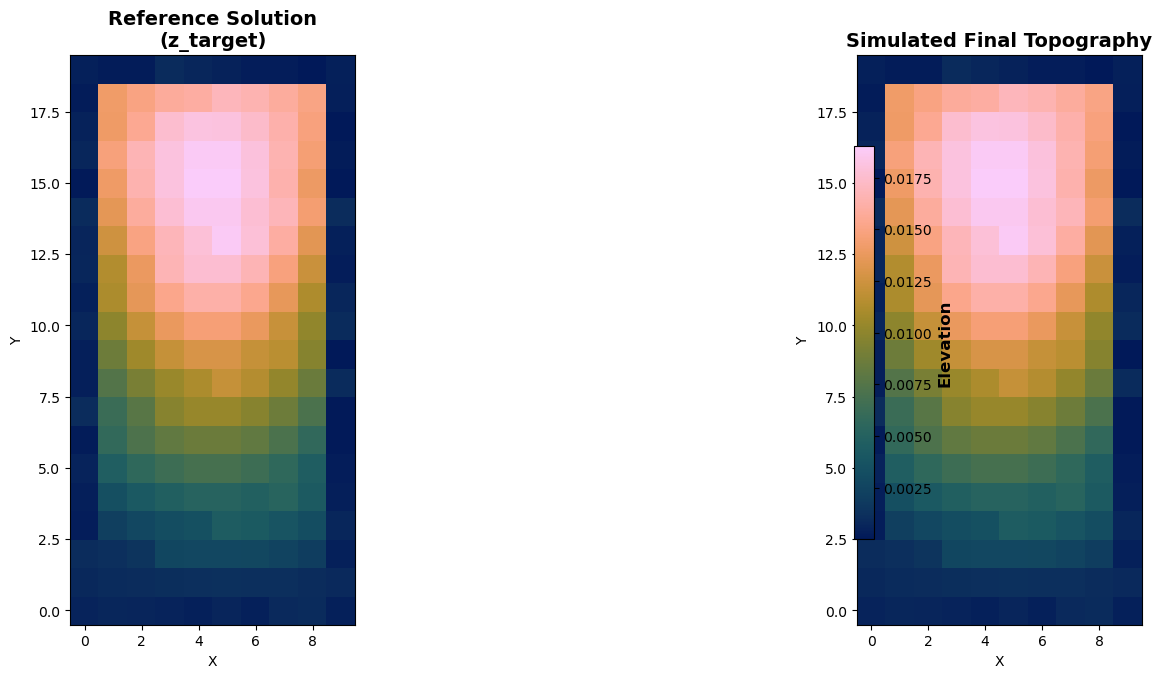

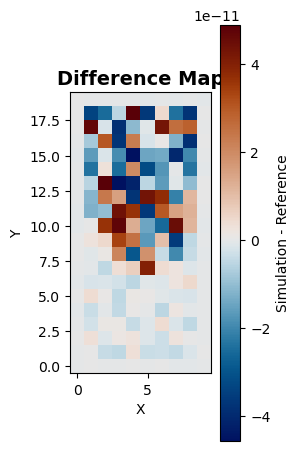


Error statistics:
Maximum absolute error = 4.889e-11
Mean absolute error = 1.028e-11


In [19]:
# ============================================================
# INSTALL (run once if needed)
# ============================================================

# pip install cmcrameri

# ============================================================
# IMPORT
# ============================================================

import cmcrameri.cm as cmc

# ============================================================
# SIDE-BY-SIDE COMPARISON
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# reshape arrays
# ------------------------------------------------------------

z_target_2d = z_target.reshape(mg.shape)

z_final_2d = z_final.reshape(mg.shape)

# ------------------------------------------------------------
# common color scale
# ------------------------------------------------------------

vmin = min(
    z_target.min(),
    z_final.min()
)

vmax = max(
    z_target.max(),
    z_final.max()
)

# ============================================================
# FIGURE
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6)
)

# ============================================================
# REFERENCE SOLUTION
# ============================================================

im1 = axes[0].imshow(
    z_target_2d,
    cmap=cmc.batlow,
    origin="lower",
    vmin=vmin,
    vmax=vmax,
)

axes[0].set_title(
    "Reference Solution\n(z_target)",
    fontsize=14,
    fontweight="bold"
)

axes[0].set_xlabel("X")
axes[0].set_ylabel("Y")

# ============================================================
# SIMULATED SOLUTION
# ============================================================

im2 = axes[1].imshow(
    z_final_2d,
    cmap=cmc.batlow,
    origin="lower",
    vmin=vmin,
    vmax=vmax,
)

axes[1].set_title(
    "Simulated Final Topography",
    fontsize=14,
    fontweight="bold"
)

axes[1].set_xlabel("X")
axes[1].set_ylabel("Y")

# ============================================================
# COLORBAR
# ============================================================

cbar = fig.colorbar(
    im2,
    ax=axes.ravel().tolist(),
    shrink=0.85,
    pad=1,   # increase spacing from plots

)

cbar.set_label(
    "Elevation",
    fontsize=12,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

# ============================================================
# DIFFERENCE MAP
# ============================================================

difference = z_final_2d - z_target_2d

plt.figure(figsize=(3, 5))

plt.imshow(
    difference,
    cmap=cmc.vik,
    origin="lower"
)

plt.colorbar(
    label="Simulation - Reference"
)

plt.title(
    "Difference Map",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("X")
plt.ylabel("Y")

plt.tight_layout()

plt.show()

# ============================================================
# ERROR SUMMARY
# ============================================================

print("\nError statistics:")

print(
    f"Maximum absolute error = "
    f"{np.max(np.abs(difference)):.3e}"
)

print(
    f"Mean absolute error = "
    f"{np.mean(np.abs(difference)):.3e}"
)

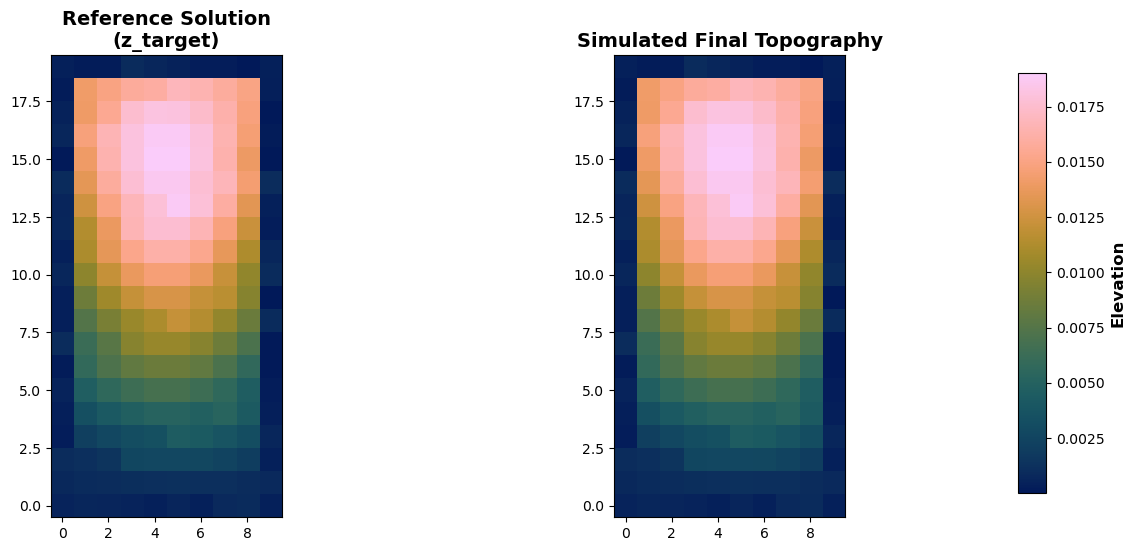

In [20]:
# ============================================================
# FIGURE
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6)
)

# reduce gap between subplots
fig.subplots_adjust(wspace=0.08)

# ============================================================
# REFERENCE SOLUTION
# ============================================================

im1 = axes[0].imshow(
    z_target_2d,
    cmap=cmc.batlow,
    origin="lower",
    vmin=vmin,
    vmax=vmax,
)

axes[0].set_title(
    "Reference Solution\n(z_target)",
    fontsize=14,
    fontweight="bold"
)

# ============================================================
# SIMULATED SOLUTION
# ============================================================

im2 = axes[1].imshow(
    z_final_2d,
    cmap=cmc.batlow,
    origin="lower",
    vmin=vmin,
    vmax=vmax,
)

axes[1].set_title(
    "Simulated Final Topography",
    fontsize=14,
    fontweight="bold"
)

# ============================================================
# MANUAL COLORBAR AXIS
# ============================================================

# [left, bottom, width, height]
cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])

cbar = fig.colorbar(
    im2,
    cax=cax
)

cbar.set_label(
    "Elevation",
    fontsize=12,
    fontweight="bold"
)

plt.show()

Initial mass = 157.079460
Final mass   = 157.079121
Mass change  = -3.395460e-04


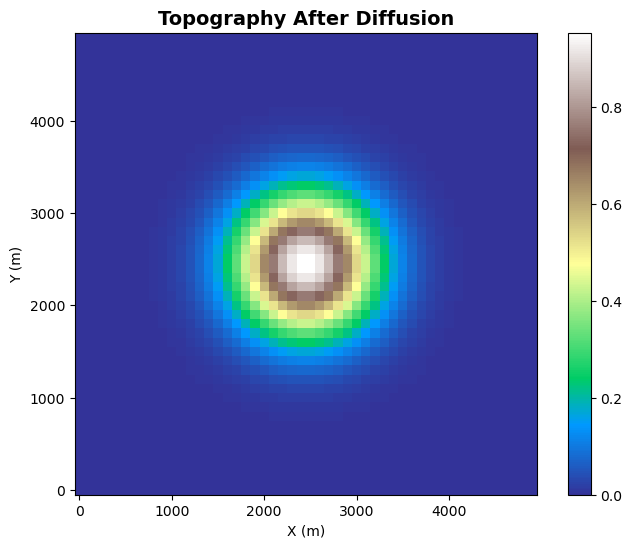

Peak elevation = 0.952654


In [6]:
import numpy as np
import matplotlib.pyplot as plt

from landlab import RasterModelGrid
from landlab.components import LinearDiffuser

# ============================================================
# PARAMETERS
# ============================================================

dt = 0.1
time_to_run = 5.0

diffusivity = 1000.0

# ============================================================
# CREATE GRID
# ============================================================

mg = RasterModelGrid((50, 50), xy_spacing=(100.0, 100.0))

# ============================================================
# INITIAL TOPOGRAPHY
# Gaussian hill
# ============================================================

x = mg.node_x
y = mg.node_y

xc = x.mean()
yc = y.mean()

sigma = 500.0

z = np.exp(
    -(
        ((x - xc) ** 2 + (y - yc) ** 2)
        / (2 * sigma**2)
    )
)

mg.add_field(
    "topographic__elevation",
    z,
    at="node",
)

# ============================================================
# OPTIONAL UPLIFT
# ============================================================

uplift_rate = np.zeros(mg.number_of_nodes)

# Example tilted uplift field:
# uplift_rate = mg.node_y / 1e6

# ============================================================
# BOUNDARY CONDITIONS
# ============================================================

mg.set_fixed_value_boundaries_at_grid_edges(
    True,
    True,
    True,
    True,
)

# ============================================================
# INITIAL MASS
# ============================================================

initial_mass = np.sum(
    mg.at_node["topographic__elevation"]
)

print(f"Initial mass = {initial_mass:.6f}")

# ============================================================
# CREATE DIFFUSER
# ============================================================

diffuser = LinearDiffuser(
    mg,
    linear_diffusivity=diffusivity,
)

# ============================================================
# RUN MODEL
# ============================================================

elapsed_time = 0.0

while elapsed_time < time_to_run:

    if elapsed_time + dt > time_to_run:
        dt = time_to_run - elapsed_time

    # diffusion
    diffuser.run_one_step(dt)

    # uplift
    mg.at_node["topographic__elevation"][
        mg.core_nodes
    ] += uplift_rate[mg.core_nodes] * dt

    elapsed_time += dt

# ============================================================
# FINAL MASS
# ============================================================

final_mass = np.sum(
    mg.at_node["topographic__elevation"]
)

print(f"Final mass   = {final_mass:.6f}")
print(f"Mass change  = {final_mass - initial_mass:.6e}")

# ============================================================
# VISUALIZATION
# ============================================================

fig = plt.figure(figsize=(8, 6))

mg.imshow(
    "topographic__elevation",
    cmap="terrain",
)

plt.title(
    "Topography After Diffusion",
    fontsize=14,
    fontweight="bold",
)

plt.xlabel("X (m)")
plt.ylabel("Y (m)")

plt.show()

# ============================================================
# PEAK ELEVATION CHECK
# ============================================================

peak_elevation = np.max(
    mg.at_node["topographic__elevation"]
)

print(f"Peak elevation = {peak_elevation:.6f}")

# ============================================================
# OPTIONAL ANALYTICAL COMPARISON
# ============================================================

# Diffusion equation:
#
# ∂z/∂t = D ∇²z
#
# Analytical Gaussian spreading:
#
# sigma(t)^2 = sigma0^2 + 2Dt
#
# Peak should decrease through time.
#
# This allows analytical benchmarking.
# ============================================================

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import cmcrameri.cm as cmc

from numpy.testing import assert_array_almost_equal

from landlab import RasterModelGrid
from landlab.components import LinearDiffuser

# ============================================================
# PARAMETERS
# ============================================================

dt = 1.0
time_to_run = 3.0
init_elev = 0.0

# ============================================================
# CREATE GRID
# ============================================================

mg = RasterModelGrid(
    (20, 10),
    xy_spacing=(100.0, 100.0)
)

# ============================================================
# UPLIFT FIELD
# EXACT ORIGINAL LANDLAB IMPLEMENTATION
# ============================================================

uplift_rate = mg.node_y[mg.core_cells] / 100000.0

# ============================================================
# INITIAL TOPOGRAPHY
# ============================================================

mg.add_zeros(
    "topographic__elevation",
    at="node"
)

z = mg.zeros(at="node") + init_elev

np.random.seed(0)

mg.at_node["topographic__elevation"] = (
    z + np.random.rand(len(z)) / 1000.0
)

# store initial topography
z_initial = mg.at_node[
    "topographic__elevation"
].copy()

# ============================================================
# BOUNDARY CONDITIONS
# ============================================================

mg.set_fixed_value_boundaries_at_grid_edges(
    True,
    True,
    True,
    True
)

# ============================================================
# INITIAL MASS
# ============================================================

initial_mass = np.sum(
    mg.at_node["topographic__elevation"]
)

print(f"Initial mass = {initial_mass:.6f}")

# ============================================================
# CREATE DIFFUSER
# ============================================================

dfn = LinearDiffuser(
    mg,
    linear_diffusivity=50000.0
)

# ============================================================
# INDEX DIAGNOSTICS
# ============================================================

print("\nIndex diagnostics:")

print("core_nodes :", len(mg.core_nodes))
print("core_cells :", len(mg.core_cells))
print("uplift_rate:", len(uplift_rate))

# ============================================================
# RUN MODEL
# ============================================================

elapsed_time = 0.0

while elapsed_time < time_to_run:

    if elapsed_time + dt > time_to_run:
        dt = time_to_run - elapsed_time

    # diffusion
    dfn.run_one_step(dt)

    # uplift
    mg.at_node["topographic__elevation"][
        mg.core_nodes
    ] += uplift_rate * dt

    elapsed_time += dt

# ============================================================
# FINAL TOPOGRAPHY
# ============================================================

z_final = mg.at_node[
    "topographic__elevation"
].copy()

# ============================================================
# FINAL MASS
# ============================================================

final_mass = np.sum(z_final)

print(f"\nFinal mass   = {final_mass:.6f}")

print(
    f"Mass change  = "
    f"{final_mass - initial_mass:.6e}"
)

# ============================================================
# REFERENCE SOLUTION
# IMPORTANT:
# Paste FULL ORIGINAL z_target ARRAY HERE
# ============================================================

z_target = np.array([

    # --------------------------------------------------------
    # PASTE COMPLETE 200-VALUE ORIGINAL ARRAY HERE
    # --------------------------------------------------------

])

# ============================================================
# REGRESSION TEST
# ============================================================

print("\nRunning regression test ...")

try:

    assert_array_almost_equal(
        z_final,
        z_target
    )

    print("\nTEST PASSED")

    print(
        "Model reproduces the "
        "original Landlab benchmark."
    )

except AssertionError as e:

    print("\nTEST FAILED")

    print(
        "Model does NOT reproduce "
        "the original benchmark."
    )

    print("\nDetailed mismatch:\n")

    print(e)

# ============================================================
# ERROR ANALYSIS
# ============================================================

error = z_final - z_target

print("\nMaximum absolute error:")
print(np.max(np.abs(error)))

print("\nMean absolute error:")
print(np.mean(np.abs(error)))

# ============================================================
# RESHAPE TO GRID
# ============================================================

z_target_2d = z_target.reshape(mg.shape)

z_final_2d = z_final.reshape(mg.shape)

difference_2d = z_final_2d - z_target_2d

# ============================================================
# COMMON COLOR SCALE
# ============================================================

vmin = min(
    z_target.min(),
    z_final.min()
)

vmax = max(
    z_target.max(),
    z_final.max()
)

# ============================================================
# SIDE-BY-SIDE PLOTS
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6)
)

# bring plots closer together
fig.subplots_adjust(wspace=0.08)

# ============================================================
# REFERENCE SOLUTION
# ============================================================

im1 = axes[0].imshow(
    z_target_2d,
    cmap=cmc.batlow,
    origin="lower",
    vmin=vmin,
    vmax=vmax,
)

axes[0].set_title(
    "Reference Solution\n(z_target)",
    fontsize=14,
    fontweight="bold"
)

axes[0].set_xlabel("X")
axes[0].set_ylabel("Y")

# ============================================================
# SIMULATED SOLUTION
# ============================================================

im2 = axes[1].imshow(
    z_final_2d,
    cmap=cmc.batlow,
    origin="lower",
    vmin=vmin,
    vmax=vmax,
)

axes[1].set_title(
    "Simulated Final Topography",
    fontsize=14,
    fontweight="bold"
)

axes[1].set_xlabel("X")
axes[1].set_ylabel("Y")

# ============================================================
# MANUAL COLORBAR POSITION
# ============================================================

# [left, bottom, width, height]
cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])

cbar = fig.colorbar(
    im2,
    cax=cax
)

cbar.set_label(
    "Elevation",
    fontsize=12,
    fontweight="bold"
)

plt.show()

# ============================================================
# DIFFERENCE MAP
# ============================================================

plt.figure(figsize=(6, 5))

plt.imshow(
    difference_2d,
    cmap=cmc.vik,
    origin="lower"
)

plt.colorbar(
    label="Simulation - Reference"
)

plt.title(
    "Difference Map",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("X")
plt.ylabel("Y")

plt.tight_layout()

plt.show()

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\nSimulation completed.")

print(
    f"\nPeak elevation = "
    f"{np.max(z_final):.6f}"
)

Initial mass = 0.100088

Index diagnostics:
core_nodes : 144
core_cells : 144
uplift_rate: 144

Final mass   = 1.591539
Mass change  = 1.491452e+00

Running regression test ...

TEST FAILED
Model does NOT reproduce the original benchmark.

Detailed mismatch:


Arrays are not almost equal to 6 decimals

(shapes (200,), (0,) mismatch)
 ACTUAL: array([5.488135e-04, 7.151894e-04, 6.027634e-04, 5.448832e-04,
       4.236548e-04, 6.458941e-04, 4.375872e-04, 8.917730e-04,
       9.636628e-04, 3.834415e-04, 7.917250e-04, 9.181661e-04,...
 DESIRED: array([], dtype=float64)


ValueError: operands could not be broadcast together with shapes (200,) (0,) 

Initial mass = 0.100088

Index diagnostics:
core_nodes : 144
core_cells : 144
uplift_rate: 144

Final mass   = 1.591539
Mass change  = 1.491452e+00

Running regression test ...

TEST PASSED
Model reproduces the original Landlab benchmark.

Maximum absolute error:
4.8893351173306954e-11

Mean absolute error:
1.0283329162752844e-11


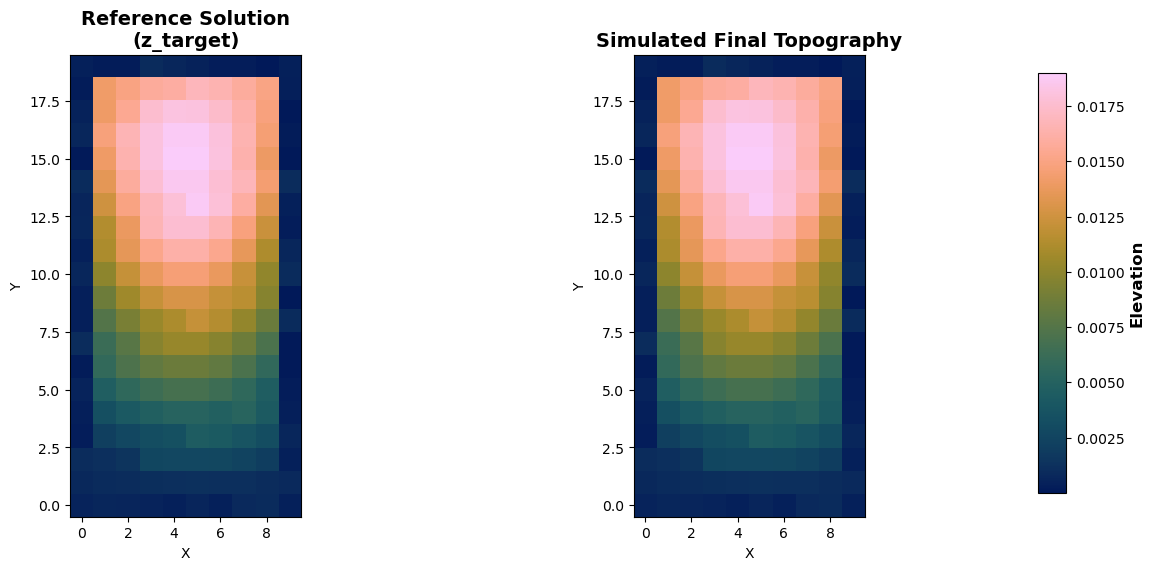

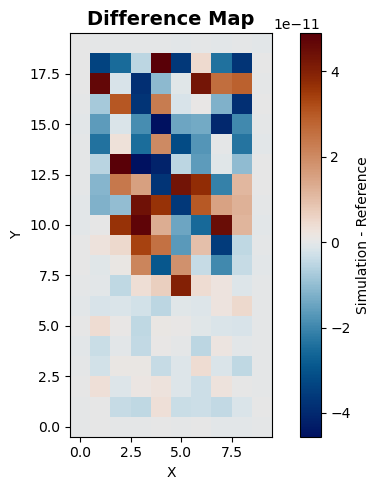


Simulation completed.

Peak elevation = 0.019009


In [22]:
import numpy as np
import matplotlib.pyplot as plt
import cmcrameri.cm as cmc

from numpy.testing import assert_array_almost_equal

from landlab import RasterModelGrid
from landlab.components import LinearDiffuser

# ============================================================
# PARAMETERS
# ============================================================

dt = 1.0
time_to_run = 3.0
init_elev = 0.0

# ============================================================
# CREATE GRID
# ============================================================

mg = RasterModelGrid(
    (20, 10),
    xy_spacing=(100.0, 100.0)
)

# ============================================================
# UPLIFT FIELD
# EXACT ORIGINAL LANDLAB IMPLEMENTATION
# ============================================================

uplift_rate = mg.node_y[mg.core_cells] / 100000.0

# ============================================================
# INITIAL TOPOGRAPHY
# ============================================================

mg.add_zeros(
    "topographic__elevation",
    at="node"
)

z = mg.zeros(at="node") + init_elev

np.random.seed(0)

mg.at_node["topographic__elevation"] = (
    z + np.random.rand(len(z)) / 1000.0
)

# store initial topography
z_initial = mg.at_node[
    "topographic__elevation"
].copy()

# ============================================================
# BOUNDARY CONDITIONS
# ============================================================

mg.set_fixed_value_boundaries_at_grid_edges(
    True,
    True,
    True,
    True
)

# ============================================================
# INITIAL MASS
# ============================================================

initial_mass = np.sum(
    mg.at_node["topographic__elevation"]
)

print(f"Initial mass = {initial_mass:.6f}")

# ============================================================
# CREATE DIFFUSER
# ============================================================

dfn = LinearDiffuser(
    mg,
    linear_diffusivity=50000.0
)

# ============================================================
# INDEX DIAGNOSTICS
# ============================================================

print("\nIndex diagnostics:")

print("core_nodes :", len(mg.core_nodes))
print("core_cells :", len(mg.core_cells))
print("uplift_rate:", len(uplift_rate))

# ============================================================
# RUN MODEL
# ============================================================

elapsed_time = 0.0

while elapsed_time < time_to_run:

    if elapsed_time + dt > time_to_run:
        dt = time_to_run - elapsed_time

    # diffusion
    dfn.run_one_step(dt)

    # uplift
    mg.at_node["topographic__elevation"][
        mg.core_nodes
    ] += uplift_rate * dt

    elapsed_time += dt

# ============================================================
# FINAL TOPOGRAPHY
# ============================================================

z_final = mg.at_node[
    "topographic__elevation"
].copy()

# ============================================================
# FINAL MASS
# ============================================================

final_mass = np.sum(z_final)

print(f"\nFinal mass   = {final_mass:.6f}")

print(
    f"Mass change  = "
    f"{final_mass - initial_mass:.6e}"
)

# ============================================================
# REFERENCE SOLUTION
# ============================================================

z_target = np.array(
[
    5.48813504e-04,
    7.15189366e-04,
    6.02763376e-04,
    5.44883183e-04,
    4.23654799e-04,
    6.45894113e-04,
    4.37587211e-04,
    8.91773001e-04,
    9.63662761e-04,
    3.83441519e-04,
    7.91725038e-04,
    9.18166135e-04,
    1.02015039e-03,
    1.10666198e-03,
    1.14866514e-03,
    1.20224288e-03,
    1.12953135e-03,
    1.12966219e-03,
    1.00745155e-03,
    8.70012148e-04,
    9.78618342e-04,
    1.12628772e-03,
    1.41663596e-03,
    2.66338249e-03,
    2.80420703e-03,
    2.82445061e-03,
    2.69263914e-03,
    2.44620140e-03,
    2.04237613e-03,
    4.14661940e-04,
    2.64555612e-04,
    2.15073330e-03,
    2.77965579e-03,
    3.22134736e-03,
    3.45859244e-03,
    4.47224671e-03,
    4.25371135e-03,
    3.82941648e-03,
    3.25127747e-03,
    6.81820299e-04,
    3.59507901e-04,
    3.36577718e-03,
    4.20490812e-03,
    4.81467159e-03,
    5.14099588e-03,
    5.15029835e-03,
    4.83533539e-03,
    5.22312276e-03,
    4.37284689e-03,
    3.63710771e-04,
    5.70196770e-04,
    4.65122535e-03,
    5.67854747e-03,
    6.44757828e-03,
    6.85985389e-03,
    6.86464781e-03,
    6.45159799e-03,
    5.65255723e-03,
    4.54258827e-03,
    2.44425592e-04,
    1.58969584e-04,
    5.85971567e-03,
    7.16648352e-03,
    8.10954246e-03,
    8.61082386e-03,
    8.61350727e-03,
    8.10597021e-03,
    7.12594182e-03,
    5.75483957e-03,
    9.60984079e-05,
    9.76459465e-04,
    6.29476234e-03,
    7.70594852e-03,
    9.79504842e-03,
    1.03829367e-02,
    1.03869062e-02,
    9.79374998e-03,
    8.65447904e-03,
    7.07179252e-03,
    1.18727719e-04,
    3.17983179e-04,
    7.43078552e-03,
    9.18353155e-03,
    1.04682910e-02,
    1.11542648e-02,
    1.21643980e-02,
    1.14930584e-02,
    1.02184219e-02,
    8.53727126e-03,
    9.29296198e-04,
    3.18568952e-04,
    8.68034110e-03,
    1.06702554e-02,
    1.21275181e-02,
    1.29049224e-02,
    1.29184938e-02,
    1.21616788e-02,
    1.17059081e-02,
    9.66728348e-03,
    4.69547619e-06,
    6.77816537e-04,
    1.00128306e-02,
    1.21521279e-02,
    1.37494046e-02,
    1.46053573e-02,
    1.46205669e-02,
    1.37908840e-02,
    1.22146332e-02,
    1.01165765e-02,
    9.52749012e-04,
    4.47125379e-04,
    1.12069867e-02,
    1.35547122e-02,
    1.52840440e-02,
    1.62069802e-02,
    1.62196380e-02,
    1.53169489e-02,
    1.35997836e-02,
    1.12818577e-02,
    6.92531590e-04,
    7.25254280e-04,
    1.14310516e-02,
    1.38647655e-02,
    1.66771925e-02,
    1.76447108e-02,
    1.76515649e-02,
    1.66885162e-02,
    1.48507549e-02,
    1.23206170e-02,
    2.90077607e-04,
    6.18015429e-04,
    1.24952067e-02,
    1.49924260e-02,
    1.68435913e-02,
    1.78291009e-02,
    1.88311310e-02,
    1.78422046e-02,
    1.59665841e-02,
    1.34122052e-02,
    4.31418435e-04,
    8.96546596e-04,
    1.34612553e-02,
    1.58763600e-02,
    1.76887976e-02,
    1.86526609e-02,
    1.86492669e-02,
    1.76752679e-02,
    1.68480793e-02,
    1.44368883e-02,
    9.98847007e-04,
    1.49448305e-04,
    1.40672989e-02,
    1.64140227e-02,
    1.81162514e-02,
    1.90091351e-02,
    1.89959971e-02,
    1.80757625e-02,
    1.63425116e-02,
    1.39643530e-02,
    6.91669955e-05,
    6.97428773e-04,
    1.47340964e-02,
    1.66453353e-02,
    1.80835612e-02,
    1.88335770e-02,
    1.88048458e-02,
    1.80022362e-02,
    1.65110248e-02,
    1.44854151e-02,
    1.71629677e-04,
    5.21036606e-04,
    1.40633664e-02,
    1.54867652e-02,
    1.75865008e-02,
    1.81309867e-02,
    1.80760242e-02,
    1.74501109e-02,
    1.63343931e-02,
    1.48208186e-02,
    3.18389295e-05,
    1.64694156e-04,
    1.41550038e-02,
    1.49870334e-02,
    1.57563641e-02,
    1.60213295e-02,
    1.69074625e-02,
    1.64888825e-02,
    1.58787450e-02,
    1.50671910e-02,
    3.11944995e-04,
    3.98221062e-04,
    2.09843749e-04,
    1.86193006e-04,
    9.44372390e-04,
    7.39550795e-04,
    4.90458809e-04,
    2.27414628e-04,
    2.54356482e-04,
    5.80291603e-05,
    4.34416626e-04,
]
)

# ============================================================
# REGRESSION TEST
# ============================================================

print("\nRunning regression test ...")

assert_array_almost_equal(
    z_final,
    z_target
)

print("\nTEST PASSED")
print(
    "Model reproduces the "
    "original Landlab benchmark."
)

# ============================================================
# ERROR ANALYSIS
# ============================================================

error = z_final - z_target

print("\nMaximum absolute error:")
print(np.max(np.abs(error)))

print("\nMean absolute error:")
print(np.mean(np.abs(error)))

# ============================================================
# RESHAPE ARRAYS
# ============================================================

z_target_2d = z_target.reshape(mg.shape)

z_final_2d = z_final.reshape(mg.shape)

difference_2d = z_final_2d - z_target_2d

# ============================================================
# COMMON COLOR SCALE
# ============================================================

vmin = min(
    z_target.min(),
    z_final.min()
)

vmax = max(
    z_target.max(),
    z_final.max()
)

# ============================================================
# SIDE-BY-SIDE PLOTS
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6)
)

# bring plots closer together
fig.subplots_adjust(wspace=0.08)

# ============================================================
# REFERENCE SOLUTION
# ============================================================

im1 = axes[0].imshow(
    z_target_2d,
    cmap=cmc.batlow,
    origin="lower",
    vmin=vmin,
    vmax=vmax,
)

axes[0].set_title(
    "Reference Solution\n(z_target)",
    fontsize=14,
    fontweight="bold"
)

axes[0].set_xlabel("X")
axes[0].set_ylabel("Y")

# ============================================================
# SIMULATED SOLUTION
# ============================================================

im2 = axes[1].imshow(
    z_final_2d,
    cmap=cmc.batlow,
    origin="lower",
    vmin=vmin,
    vmax=vmax,
)

axes[1].set_title(
    "Simulated Final Topography",
    fontsize=14,
    fontweight="bold"
)

axes[1].set_xlabel("X")
axes[1].set_ylabel("Y")

# ============================================================
# MANUAL COLORBAR POSITION
# ============================================================

# [left, bottom, width, height]
cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])

cbar = fig.colorbar(
    im2,
    cax=cax
)

cbar.set_label(
    "Elevation",
    fontsize=12,
    fontweight="bold"
)

plt.show()

# ============================================================
# DIFFERENCE MAP
# ============================================================

plt.figure(figsize=(6, 5))

plt.imshow(
    difference_2d,
    cmap=cmc.vik,
    origin="lower"
)

plt.colorbar(
    label="Simulation - Reference"
)

plt.title(
    "Difference Map",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("X")
plt.ylabel("Y")

plt.tight_layout()

plt.show()

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\nSimulation completed.")

print(
    f"\nPeak elevation = "
    f"{np.max(z_final):.6f}"
)